In [2]:
import numpy as np
import math
from sklearn.cluster import AffinityPropagation

def GetCorespondingMatrix_LG(List01):
    SQRTLEN = int(len(List01)/2)
    OutMatrix = np.random.randint(8,9,(SQRTLEN, 2))
    for i in range(0, len(List01)):
        OutMatrix[i//2][i%2] = int(List01[i])
    return OutMatrix

def GetConfigurationAndWTTP(TargetString):
    OutMatrix = String012ToMatrix(TargetString.split()[0])
    OutMatrix_LG = GetCorespondingMatrix_LG(TargetString.split()[1])
    New_String = TargetString.split()[2].split(';')
    WTTP = []
    for i in range(0, len(New_String)):
        if len(New_String[i]) != 0:
            Temp_List = []
            for j in range(0, len(New_String[i].split(','))):
                Temp_List.append(int(New_String[i].split(',')[j]))
            WTTP.append(Temp_List)
        else:
            pass
    WTTP = np.array(WTTP)
    outWTTP = {}
    for i in range(0, len(WTTP)):
        outWTTP[str(i)] = [[], WTTP[i]]
    return OutMatrix, OutMatrix_LG, outWTTP

def AlphaTestResultCheck(path_, VarianceThreshold, NumLines):
    # Just take the highest frequent configuration value
    #AlphaTestResultFile = open('/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test/AlphaTest_Results/EGRN_AlphaTest_G{}_C{}.txt'.format(GNum, CNum) , 'r')
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    NumCount = 0
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
        NumCount = NumCount + 1
        if NumCount == NumLines:
            break
        else:
            pass
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    InsignificantEntries = []
    for keys in FrequencyDic:
        #print(np.var(FrequencyDic[keys]),3)
        if round(np.var(FrequencyDic[keys]),3) < VarianceThreshold:
            InsignificantEntries.append(keys)
        else:
            pass
    #print(FrequencyDic,'\n',InsignificantEntries)
    OutStringList = []
    for keys in FrequencyDic:
        MaxIndexList = np.argwhere(FrequencyDic[keys] == np.amax(FrequencyDic[keys])).flatten().tolist()
        OutStringList.append(str(np.random.choice(MaxIndexList)))
    #print(OutStringList)
    for i in range(0, len(InsignificantEntries)):
        OutStringList[int(InsignificantEntries[i])] = np.random.choice(['0','1','2'])
    #print(OutStringList)
    #print(len(InsignificantEntries))
    OutString = ''
    for i in range(0, len(OutStringList)):
        OutString = OutString + OutStringList[i]
    return OutString

def AlphaTestResultCheck_LG_New(path_, VarianceThreshold):
    # Just take the highest frequent configuration value
    #AlphaTestResultFile = open('/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test/AlphaTest_Results/EGRN_AlphaTest_G{}_C{}.txt'.format(GNum, CNum) , 'r')
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[2]
        ResultConfigurations.append(line_splited[3])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    InsignificantEntries = []
    for keys in FrequencyDic:
        if round(np.var(FrequencyDic[keys]),3) < VarianceThreshold:
            InsignificantEntries.append(keys)
        else:
            pass
    #print(FrequencyDic,'\n',InsignificantEntries)
    OutStringList = []
    for keys in FrequencyDic:
        MaxIndexList = np.argwhere(FrequencyDic[keys] == np.amax(FrequencyDic[keys])).flatten().tolist()
        OutStringList.append(str(np.random.choice(MaxIndexList)))
    #print(OutStringList)
    for i in range(0, len(InsignificantEntries)):
        OutStringList[int(InsignificantEntries[i])] = np.random.choice(['0','1'])
    #print(len(InsignificantEntries))
        
    ARString = ''
    AMString = AlphaTestResultCheck(path,-1,30)
    for TargetGene in range(0, TotalNumberOfGenes):
        ARString = ''
        for stin in range(0, len(AMString)):
            if stin%TotalNumberOfGenes == TargetGene:
                ARString = ARString + AMString[stin]
        count_1 = 0
        count_2 = 0
        for each in ARString:
            if each == '1':
                count_1 = count_1 + 1
            elif each == '2':
                count_2 = count_2 + 1
            else:
                pass
        #print(count_1, count_2)
        if count_1 <= 1:
            OutStringList[2*TargetGene] = '0'
        else:
            pass
        if count_2 <= 1:
            OutStringList[2*TargetGene+1] = '0'
        else:
            pass
    OutString = ''
    for i in range(0, len(OutStringList)):
        OutString = OutString + OutStringList[i]
    return OutString

def AlphaTestResultCheck_LG(path_, VarianceThreshold):
    # Just take the highest frequent configuration value
    #AlphaTestResultFile = open('/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test/AlphaTest_Results/EGRN_AlphaTest_G{}_C{}.txt'.format(GNum, CNum) , 'r')
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[2]
        ResultConfigurations.append(line_splited[3])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    InsignificantEntries = []
    for keys in FrequencyDic:
        if round(np.var(FrequencyDic[keys]),3) < VarianceThreshold:
            InsignificantEntries.append(keys)
        else:
            pass
    #print(FrequencyDic,'\n',InsignificantEntries)
    OutStringList = []
    for keys in FrequencyDic:
        MaxIndexList = np.argwhere(FrequencyDic[keys] == np.amax(FrequencyDic[keys])).flatten().tolist()
        OutStringList.append(str(np.random.choice(MaxIndexList)))
    #print(OutStringList)
    for i in range(0, len(InsignificantEntries)):
        OutStringList[int(InsignificantEntries[i])] = np.random.choice(['0','1'])
    #print(len(InsignificantEntries))
    OutString = ''
    for i in range(0, len(OutStringList)):
        OutString = OutString + OutStringList[i]
    return OutString

def Matrix2String01_LG(_Matrix):
    OutString01 = ''
    for i in range(0, _Matrix.shape[0]):
        for j in range(0, _Matrix.shape[1]):
            OutString01 = OutString01 + str(_Matrix[i][j])
    return OutString01

def GetHammingDistance_LG(_MA, _MB):
    HammingDis = 0
    _SA = Matrix2String01_LG(_MA)
    _SB = Matrix2String01_LG(_MB)
    for i in range(0, len(_SA)):
        if _SA[i] == _SB[i]:
            pass
        else:
            HammingDis = HammingDis + 1
    return HammingDis

def LogicGatesMatrix2String(matrix):
    outstring = ''
    for i in range(0, matrix.shape[0]):
        for j in range(0, matrix.shape[1]):
            outstring = outstring + str(matrix[i][j])
    return outstring

def process_f0(path_):
    infile = open(path_[0:-4]+'_f0.txt')
    f0_colletor = []
    GetNextLine = False
    counter_f0 = 0
    for line in infile:
        if GetNextLine:
            f0_colletor[-1] = f0_colletor[-1]+line
            GetNextLine = False
        else:
            pass
        if counter_f0 == 2:
            if ']' in line:
                f0_colletor.append(line)
            else:
                GetNextLine = True
                f0_colletor.append(line)
            counter_f0 = 0
        else:
            pass
        if line[0] in ['0', '1', '2']:
            counter_f0 = counter_f0 + 1
        else:
            pass
    f0_matrix = []
    for lf0 in range(0, len(f0_colletor)):
        f0_matrix.append(f0_colletor[lf0][1:-2].split(','))
    #print(f0_matrix)
    for mf0 in range(0, len(f0_matrix)):
        for nf0 in range(0, len(f0_matrix[mf0])):
            f0_matrix[mf0][nf0] = float(f0_matrix[mf0][nf0])
    #print(np.mean(f0_matrix, axis=0))
    #clustering = AffinityPropagation(random_state=2).fit(f0_matrix)
    #print(len(clustering.cluster_centers_))
    return np.mean(f0_matrix, axis=0), np.std(f0_matrix), np.round(f0_matrix,4)

def LogicGatesString2Matrix(string):
    outmatrix = np.random.randint(3,4,(int(len(string)/2),2))
    stringindex = 0
    for i in range(0, outmatrix.shape[0]):
        for j in range(0, outmatrix.shape[1]):
            outmatrix[i][j] = int(string[stringindex])
            stringindex = stringindex + 1
    return outmatrix

def String012ToMatrix(List012):
    # String '012' to Matrix
    SQRTLEN = int(np.sqrt(len(List012)))
    OutMatrix = np.random.randint(8,9,(2, SQRTLEN, SQRTLEN))
    for i in range(0, len(List012)):
        if List012[i] == '0':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 0
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 0
        elif List012[i] == '1':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 1
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 0
        elif List012[i] == '2':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 0
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 1
        else:
            raise Exception('List012 must just have 012!\n{}'.format(List012))
    return OutMatrix

def GetHammingDistance(_MatrixA, _MatrixB):
    HammingDistance = 0
    if _MatrixA.shape == _MatrixB.shape:
        for i in range(0, _MatrixA.shape[0]):
            for j in range(0, _MatrixA.shape[1]):
                for z in range(0, _MatrixA.shape[2]):
                    if _MatrixA[i,j,z] != _MatrixB[i,j,z]:
                        HammingDistance = HammingDistance + 1
                    else:
                        pass
    else:
        raise Exception('Shapes don\'t match!')
    return HammingDistance

def ConfigurationTo012(ConfigurationMatrix):
    OutString = ''
    for j in range(0, ConfigurationMatrix.shape[1]):
        for z in range(0, ConfigurationMatrix.shape[2]):
            if ConfigurationMatrix[0][j][z] == 0 and ConfigurationMatrix[1][j][z] == 0:
                OutString = OutString + '0'
            elif ConfigurationMatrix[0][j][z] == 1 and ConfigurationMatrix[1][j][z] == 0:
                OutString = OutString + '1'
            elif ConfigurationMatrix[0][j][z] == 0 and ConfigurationMatrix[1][j][z] == 1:
                OutString = OutString + '2'
            else:
                raise Exception('Configuration (1,1)!')
    return OutString

def GetPossibleNetworksGivenHammingDistance(NNum_, HNum, ReferenceConfiguration):
    NNum = NNum_**2
    MNum = 0
    ReferenceConfiguration012 = ConfigurationTo012(ReferenceConfiguration)
    for i in ReferenceConfiguration012:
        if i == '0':
            pass
        else:
            MNum = MNum + 1
    lowerk = max(HNum - NNum, 0)
    upperk = min(int(np.floor(HNum*0.5)),MNum)
    Output = 0
    for k in range(lowerk, upperk+1):
        Output = Output + 2**(HNum-2*k)*(np.math.factorial(MNum)/(np.math.factorial(k)*np.math.factorial(MNum-k)))*(np.math.factorial(NNum-k)/(np.math.factorial(HNum-2*k)*np.math.factorial(NNum+k-HNum)))
    return(Output)

def GetPossibleNetworksGivenHammingDistance_LG(NNum_, HNum):
    return np.math.factorial(NNum_*2)/(np.math.factorial(HNum)*np.math.factorial(NNum_*2-HNum))
#############################################################################################################################
TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    #TargetString = '1200101000001000021010000	1000000000	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'    
    TargetString = '0100000100100110020020000	0000000000	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'    
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	000000000000	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	00000010000010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	0000000000000010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	100010101000000000	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'

# BetaTestComplete
#TargetString = '000200000020000200000020000002000000	000000010101	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;' 
ReferenceConfiguration, ReferenceLogicGates, WTTP = GetConfigurationAndWTTP(TargetString)
#############################################################################################################################
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/G{}_Noise/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/G{}_ChIP/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/G{}_P/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_Ecoli/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans/All_Attractors/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/G{}_Newf0/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans_New/Duplets/Test2/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_Yeast_Edge/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/syntren/G{}_Noise/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans_New/Duplets/Test9_R2/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans_New/All_ChIP_1.5/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)


infile = open(path, 'r')
HammingList = []
ContentList = []
HammingList_LG = []
for line in infile:
    ContentList.append(float(line.split()[6]))
    HammingList.append(int(line.split()[5]))
    HammingList_LG.append(int(line.split()[4]))
ContentList = np.array(ContentList)
HammingList = np.array(HammingList)
HammingList_LG = np.array(HammingList_LG)

C_Total = 0
for i in range(0, 2*TotalNumberOfGenes**2):
    C_Total = C_Total + GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes,i,ReferenceConfiguration)

LG_Total = 0
for i in range(0, TotalNumberOfGenes*2):
    LG_Total = LG_Total + GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, i)


AverageOutput = 0
Ave_Configuration = 0
Ave_LogicGate = 0
for i in range(0, len(HammingList)):
    Configuration_ = 0
    for P in range(0, HammingList[i]+1):
        Configuration_ = Configuration_ + GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes,P,ReferenceConfiguration)
    LogicGates_ = 0
    for j in range(0, HammingList_LG[i]+1):
        LogicGates_ = LogicGates_ + GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)
    AverageOutput = AverageOutput + Configuration_*LogicGates_
    Ave_Configuration = Ave_Configuration + Configuration_
    Ave_LogicGate = Ave_LogicGate + LogicGates_
#AverageOutput = AverageOutput/(len(HammingList)*FenMu)
print('Configuration Percentile: ', Ave_Configuration/(len(HammingList)*C_Total))
print('Logic Gates Percentile: ', Ave_LogicGate/(len(HammingList)*LG_Total))


#############################################################################################################################

#############################################################################################################################

print(ReferenceConfiguration.shape)
C_String = TargetString.split('\t')[0]
sum_HD_C = 0
supp_0 = 0
supp_1 = 0
supp_2 = 0
for i in range(0, TotalNumberOfGenes**2):
    if C_String[i] == '0':
        sum_HD_C = sum_HD_C + (1/3)*0 + (1/3)*1 + (1/3)*1
        supp_0 = supp_0 + 1
    elif C_String[i] == '1':
        sum_HD_C = sum_HD_C + (1/3)*1 + (1/3)*0 + (1/3)*2
        supp_1 = supp_1 + 1
    elif C_String[i] == '2':
        sum_HD_C = sum_HD_C + (1/3)*1 + (1/3)*2 + (1/3)*0 
        supp_2 = supp_2 + 1
    else:
        raise Exception('Wrong String')
    
ConfigurationHamming_ = 0
for P in range(0, int(sum_HD_C)+1):
    ConfigurationHamming_ = ConfigurationHamming_ + GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes, P, ReferenceConfiguration)
ConfigurationHamming_ = ConfigurationHamming_ + (sum_HD_C - int(sum_HD_C)) * GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes, int(sum_HD_C)+1, ReferenceConfiguration)
    
print('Configuration -> Precision_Control: ', np.round((supp_0**2+supp_1**2+supp_2**2)/((supp_0+supp_1+supp_2)**2),3), 'Accuracy: ', np.round(1/3,3), 'Recall_Control: ', np.round(1/3,3), 'HammingDistance_Control: ', np.round(sum_HD_C,3), 'Percentile_Control: ', round(100*ConfigurationHamming_/C_Total,3), '%')
savepercentile = round(100*ConfigurationHamming_/C_Total,3)

LG_String = TargetString.split('\t')[1]
sum_HD_LG = 0
supp_0_lg = 0
supp_1_lg = 0
for i in range(0, TotalNumberOfGenes*2):
    if LG_String[i] == '0':
        sum_HD_LG = sum_HD_LG + (1/2)*0 + (1/2)*1
        supp_0_lg = supp_0_lg + 1
    elif LG_String[i] == '1':
        sum_HD_LG = sum_HD_LG + (1/2)*1 + (1/2)*0
        supp_1_lg = supp_1_lg + 1
    else:
        raise Exception('Wrong String')

LogicGateHamming_ = 0
for j in range(0, int(sum_HD_LG)+1):
    LogicGateHamming_ = LogicGateHamming_ + GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)
LogicGateHamming_ = LogicGateHamming_ + (sum_HD_LG - int(sum_HD_LG)) * GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)


print('LogicGates -> Precision_Control: ', np.round((supp_1_lg**2+supp_0_lg**2)/((supp_0_lg+supp_1_lg)**2), 3), 'Accuracy: ', 0.5, 'Recall_Control: ', 0.5, 'HammingDistance_Control: ', np.round(sum_HD_LG,3), 'Percentile_Control: ', round(100*LogicGateHamming_/LG_Total,3), '%')
#print(TP,FP,LG_String)


#############################################################################################################################                
Ave_HC = []
Percentile_HC = []
Ave_HLG = []
Percentile_HLG = []
for xmi in range(0, 2000):
    H_C = GetHammingDistance(String012ToMatrix(AlphaTestResultCheck(path,-1,30)),ReferenceConfiguration)
    Ave_HC.append(H_C)
    H_LG = GetHammingDistance_LG(LogicGatesString2Matrix(AlphaTestResultCheck_LG_New(path,-1)),ReferenceLogicGates)
    Ave_HLG.append(H_LG)
    ConfigurationHamming_ = 0
    for P in range(0, H_C+1):
        ConfigurationHamming_ = ConfigurationHamming_ + GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes,P, ReferenceConfiguration)
    LogicGateHamming_ = 0
    for j in range(0, H_LG+1):
        LogicGateHamming_ = LogicGateHamming_ + GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)
    Percentile_HC.append(100*ConfigurationHamming_/C_Total)
    Percentile_HLG.append(100*LogicGateHamming_/LG_Total)

Ave_HC = np.array(Ave_HC)
Percentile_HC = np.array(Percentile_HC)
Ave_HLG = np.array(Ave_HLG)
Percentile_HLG = np.array(Percentile_HLG)
print('Configuration -> ', np.round(np.mean(Ave_HC),3), np.mean(Percentile_HC),'%')
print('LogicGates -> ', np.round(np.mean(Ave_HLG),2), np.round(np.mean(Percentile_HLG),2),'%')
print('Average_f0 -> ', list(np.round(process_f0(path)[0], 3)),  process_f0(path)[1])
infile.close()
print(AlphaTestResultCheck(path,-1,30))
print(AlphaTestResultCheck_LG_New(path,-1))

Configuration Percentile:  0.00223568579919515
Logic Gates Percentile:  0.7149369149369149
(2, 6, 6)
Configuration -> Precision_Control:  0.636 Accuracy:  0.333 Recall_Control:  0.333 HammingDistance_Control:  26.667 Percentile_Control:  55.754 %
LogicGates -> Precision_Control:  1.0 Accuracy:  0.5 Recall_Control:  0.5 HammingDistance_Control:  6.0 Percentile_Control:  61.294 %
Configuration ->  7.514 8.212587845980179e-07 %
LogicGates ->  3.0 7.3 %
Average_f0 ->  [0.023, 0.043, 0.018, 0.07, 0.004, 0.028] 0.14185756224271473
102000112002221001000120000210000001
100001000010


In [2]:
import numpy as np

def GetVarAM(TotalNumberOfGenes):

    path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/AlphaTest/syntren/G{}_Noise/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

    infile = open(path, 'r')
    V_M = []
    for line in infile:
        V_M.append([])
        for each in line.split()[1]:
            if int(each) == 2:
                each = -1
            else:
                pass
            V_M[-1].append(int(each))
    infile.close()
    V_M = np.array(V_M)
    sum_VM = 0
    VM_List = []
    for i in range(0, TotalNumberOfGenes**2):
        sum_VM = sum_VM + (np.var(V_M[:,i]))
        VM_List.append(np.round(np.var(V_M[:,i]), 2))
    #print(sum_VM/TotalNumberOfGenes**2)
    print(VM_List)
    return VM_List

GRN_9 = np.array(GetVarAM(9))
GRN_8 = np.array(GetVarAM(8))
GRN_7 = np.array(GetVarAM(7))
GRN_6 = np.array(GetVarAM(6))
GRN_5 = np.array(GetVarAM(5))
#print(GRN_5>=5, max(GRN_6), max(GRN_7), max(GRN_8), max(GRN_9))

[0.31, 0.33, 0.1, 0.4, 0.16, 0.29, 0.26, 0.22, 0.13, 0.2, 0.33, 0.23, 0.4, 0.22, 0.23, 0.14, 0.29, 0.16, 0.4, 0.29, 0.4, 0.36, 0.12, 0.26, 0.31, 0.41, 0.3, 0.13, 0.3, 0.14, 0.42, 0.23, 0.25, 0.1, 0.25, 0.26, 0.32, 0.31, 0.13, 0.34, 0.25, 0.36, 0.21, 0.38, 0.3, 0.27, 0.22, 0.23, 0.42, 0.29, 0.31, 0.13, 0.13, 0.25, 0.18, 0.36, 0.1, 0.33, 0.22, 0.18, 0.45, 0.3, 0.32, 0.26, 0.37, 0.17, 0.13, 0.2, 0.33, 0.29, 0.38, 0.27, 0.33, 0.36, 0.13, 0.29, 0.13, 0.26, 0.27, 0.26, 0.49]
[0.45, 0.4, 0.36, 0.22, 0.38, 0.27, 0.23, 0.22, 0.32, 0.38, 0.33, 0.34, 0.41, 0.27, 0.36, 0.47, 0.33, 0.31, 0.2, 0.33, 0.36, 0.42, 0.29, 0.4, 0.23, 0.25, 0.32, 0.37, 0.24, 0.25, 0.25, 0.28, 0.38, 0.36, 0.26, 0.38, 0.64, 0.25, 0.18, 0.4, 0.29, 0.33, 0.49, 0.4, 0.34, 0.38, 0.47, 0.18, 0.29, 0.33, 0.25, 0.37, 0.34, 0.38, 0.51, 0.13, 0.36, 0.34, 0.32, 0.34, 0.29, 0.25, 0.27, 0.76]
[0.45, 0.27, 0.41, 0.3, 0.29, 0.51, 0.24, 0.31, 0.49, 0.4, 0.31, 0.24, 0.29, 0.22, 0.23, 0.6, 0.51, 0.27, 0.41, 0.2, 0.1, 0.33, 0.31, 0.36, 0.54, 

Text(0, 0.5, 'Number of Edges')

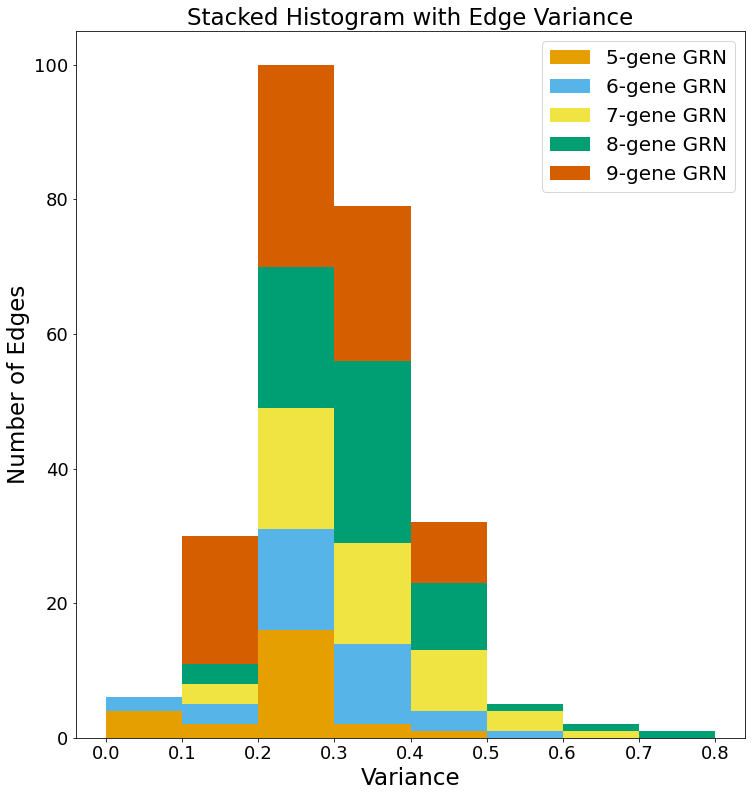

In [3]:
import seaborn as sns
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(12,13))
colors = ['#E69F00', '#56B4E9', '#F0E442', '#009E73', '#D55E00']
samples = [GRN_5, GRN_6, GRN_7, GRN_8, GRN_9]
Labels = ['5-gene GRN', '6-gene GRN', '7-gene GRN', '8-gene GRN', '9-gene GRN']
# Iterate through the five airlines
plt.hist([GRN_5, GRN_6, GRN_7, GRN_8, GRN_9], bins=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8], stacked=True, color = colors, label=Labels)
    
# Plot formatting
plt.legend(prop={'size': 20})
plt.title('Stacked Histogram with Edge Variance', fontsize=23)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('Variance', fontsize=23)
plt.ylabel('Number of Edges', fontsize=23)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(20,20))
fig = plt.figure(figsize=(20,20))
gs = fig.add_gridspec(3, hspace=0)
ax1, ax2, ax3 = gs.subplots(sharex=True, sharey=True)
my_colormap = ['#B6DBFFFF', '#FFFF6DFF', '#924900FF', '#B66DFFFF', '#DB6D00FF', '#FFB6DBFF', '#490092FF', '#006DDBFF', '#009292FF', '#6DB6FFFF', '#920000FF', '#924900FF', '#24FF24FF' ]

size = 5
x = np.arange(size)
a = np.array([[0.333333333,0.52,0.318181818,0.361702128,0.504132231,0.516129032,0.6,0.538461538,0.25],
             [0.469026549,0.577464789,0.459459459,0.473684211,0.617834395,0.459459459,0.666666667,0.472361809,0.533333333],
              [0.407894737,0.518716578,0.383561644,0.395973154,0.523809524,0.323308271,0.4,0.371727749,0.2],
              [0.255319149,0.393063584,0.25,0.244604317,0.426229508,0,0.461538462,0,0.352941176],
              [0.338235294,0.464285714,0.314720812,0.325,0.383561644,0,0.181818182,0,0.142857143]
             ]).T
b = np.array([[0.485784314,0.56127451,0.493137255,0.506862745,0.612254902,0.642647059,0.588235294,0.651169591,0.390350877],
             [0.62202381,0.704464286,0.653571429,0.67827381,0.620535714,0.764583333,0.785714286,0.782348112,0.716748768],
              [0.613963964,0.66981982,0.647897898,0.665615616,0.601051051,0.788138138,0.702702703,0.797205285,0.603658537],
              [0.572380952,0.631809524,0.611428571,0.621904762,0.572190476,0.749714286,0.748571429,0.776100629,0.642367067],
              [0.581775426,0.700764256,0.640564374,0.678248089,0.611346267,0.784244562,0.504409171,0.780938003,0.376811594]
             ]).T
c = np.array([[0.649181548,0.753263889,0.645208333,0.676264881,0.871111111,0.905527447,0.579166667,0.844124863,0.282185033],
             [0.667599206,0.788680556,0.685251323,0.715845509,0.665831934,0.940545635,1,0.960547653,0.685119048],
              [0.646265532,0.725761684,0.657115647,0.681005268,0.647504857,0.939954305,0.75974026,0.871117796,0.433779803],
              [0.494179881,0.53880445,0.524761126,0.516707475,0.539663921,0.70903667,0.781564864,0.690385123,0.59170377],
              [0.503374419,0.594030219,0.528066068,0.554849256,0.591519347,0.780360732,0.359795713,0.641606511,0.221259431]
             ]).T

total_width, n = 0.8, 9
width = total_width / n
x = x - (total_width - width) / 2

ax1.set_ylim([0, 1.1])
ax1.bar(x, a[0],  width=width, label='ARACNE', color=my_colormap[1], linewidth=2, edgecolor='black')
ax1.bar(x + width, a[1], width=width, label='CLR', color=my_colormap[2], linewidth=2, edgecolor='black')
ax1.bar(x + 2 * width, a[2], width=width, label='MRNET', color=my_colormap[8], linewidth=2, edgecolor='black')
ax1.bar(x + 3 * width, a[3], width=width, label='MRNETB', color=my_colormap[4], linewidth=2, edgecolor='black')
ax1.bar(x + 4 * width, a[4], width=width, label='SIMONE', color=my_colormap[5], linewidth=2, edgecolor='black')
ax1.bar(x + 5 * width, a[5], width=width, label='GENIE3_SYM', color=my_colormap[3], linewidth=2, edgecolor='black')
ax1.bar(x + 6 * width, a[6], width=width, label='EA_SYM', color=my_colormap[0], linewidth=4, edgecolor='black')
ax1.bar(x + 7 * width, a[7], width=width, label='GENIE3', color=my_colormap[6], linewidth=2, edgecolor='black')
ax1.bar(x + 8 * width, a[8], width=width, label='EA', color=my_colormap[9], linewidth=4, edgecolor='black')
ax1.text(x[0] + 5.6 * width, a[6][0], '*', fontsize=25)
ax1.text(x[0] + 6.6 * width, a[7][0], '*', fontsize=25)
ax1.text(x[1] + 5.6 * width, a[6][1], '*', fontsize=25)
ax1.text(x[1] + 7.6 * width, a[8][1], '*', fontsize=25)
ax1.text(x[2] + 3.6 * width, a[4][2], '*', fontsize=25)
ax1.text(x[2] + 6.6 * width, a[7][2], '*', fontsize=25)
ax1.text(x[3] + 5.6 * width, a[6][3], '*', fontsize=25)
ax1.text(x[3] + 7.6 * width, a[8][3], '*', fontsize=25)
ax1.text(x[4] + 0.6 * width, a[1][4], '*', fontsize=25)
ax1.text(x[4] + 7.6 * width, a[8][4], '*', fontsize=25)
ax1.set_ylabel('F1 score', fontsize=25)



ax2.bar(x, b[0],  width=width, label='ARACNE', color=my_colormap[1], linewidth=2, edgecolor='black')
ax2.bar(x + width, b[1], width=width, label='CLR', color=my_colormap[2], linewidth=2, edgecolor='black')
ax2.bar(x + 2 * width, b[2], width=width, label='MRNET', color=my_colormap[8], linewidth=2, edgecolor='black')
ax2.bar(x + 3 * width, b[3], width=width, label='MRNETB', color=my_colormap[4], linewidth=2, edgecolor='black')
ax2.bar(x + 4 * width, b[4], width=width, label='SIMONE', color=my_colormap[5], linewidth=2, edgecolor='black')
ax2.bar(x + 5 * width, b[5], width=width, label='GENIE3_SYM', color=my_colormap[3], linewidth=2, edgecolor='black')
ax2.bar(x + 6 * width, b[6], width=width, label='EA_SYM', color=my_colormap[0], linewidth=4, edgecolor='black')
ax2.bar(x + 7 * width, b[7], width=width, label='GENIE3', color=my_colormap[6], linewidth=2, edgecolor='black')
ax2.bar(x + 8 * width, b[8], width=width, label='EA', color=my_colormap[9], linewidth=4, edgecolor='black')
ax2.text(x[0] + 4.6 * width, b[5][0], '*', fontsize=25)
ax2.text(x[0] + 6.6 * width, b[7][0], '*', fontsize=25)
ax2.text(x[1] + 5.6 * width, b[6][1], '*', fontsize=25)
ax2.text(x[1] + 6.6 * width, b[7][1], '*', fontsize=25)
ax2.text(x[2] + 4.6 * width, b[5][2], '*', fontsize=25)
ax2.text(x[2] + 6.6 * width, b[7][2], '*', fontsize=25)
ax2.text(x[3] + 4.6 * width, b[5][3], '*', fontsize=25)
ax2.text(x[3] + 6.6 * width, b[7][3], '*', fontsize=25)
ax2.text(x[4] + 4.6 * width, b[5][4], '*', fontsize=25)
ax2.text(x[4] + 6.6 * width, b[7][4], '*', fontsize=25)
ax2.set_ylabel('AUROC', fontsize=25)




ax3.bar(x, c[0],  width=width, label='ARACNE', color=my_colormap[1], linewidth=2, edgecolor='black')
ax3.bar(x + width, c[1], width=width, label='CLR', color=my_colormap[2], linewidth=2, edgecolor='black')
ax3.bar(x + 2 * width, c[2], width=width, label='MRNET', color=my_colormap[8], linewidth=2, edgecolor='black')
ax3.bar(x + 3 * width, c[3], width=width, label='MRNETB', color=my_colormap[4], linewidth=2, edgecolor='black')
ax3.bar(x + 4 * width, c[4], width=width, label='SIMONE', color=my_colormap[5], linewidth=2, edgecolor='black')
ax3.bar(x + 5 * width, c[5], width=width, label='GENIE3_SYM', color=my_colormap[3], linewidth=2, edgecolor='black')
ax3.bar(x + 6 * width, c[6], width=width, label='EA_SYM', color=my_colormap[0], linewidth=4, edgecolor='black')
ax3.bar(x + 7 * width, c[7], width=width, label='GENIE3', color=my_colormap[6], linewidth=2, edgecolor='black')
ax3.bar(x + 8 * width, c[8], width=width, label='EA', color=my_colormap[9], linewidth=4, edgecolor='black')
ax3.text(x[0] + 4.6 * width, c[5][0], '*', fontsize=25)
ax3.text(x[0] + 6.6 * width, c[7][0], '*', fontsize=25)
ax3.text(x[1] + 5.6 * width, c[6][1], '*', fontsize=25)
ax3.text(x[1] + 6.6 * width, c[7][1], '*', fontsize=25)
ax3.text(x[2] + 4.6 * width, c[5][2], '*', fontsize=25)
ax3.text(x[2] + 6.6 * width, c[7][2], '*', fontsize=25)
ax3.text(x[3] + 5.6 * width, c[6][3], '*', fontsize=25)
ax3.text(x[3] + 6.6 * width, c[7][3], '*', fontsize=25)
ax3.text(x[4] + 4.6 * width, c[5][4], '*', fontsize=25)
ax3.text(x[4] + 6.6 * width, c[7][4], '*', fontsize=25)
ax3.set_ylabel('AUPRC', fontsize=25)




ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.),
          fancybox=True, shadow=True, ncol=5, prop={'size': 20})
plt.xticks(x + 4 * width, ['5-gene GRN', '6-gene GRN', '7-gene GRN', '8-gene GRN', '9-gene GRN'],fontsize=25)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
TP = []
TN = []
FP = []
FN = []

for R in range(1, 31):
    inputfile = pd.read_csv('C:/Users/13234/OneDrive - University of California Merced/Desktop/test/{}_OneHalfCutoff_GRN-9.csv'.format(R), header=[0], index_col=0)
    TP.append(np.array(inputfile['TP']))
    TN.append(np.array(inputfile['TN']))
    FP.append(np.array(inputfile['TP']))
    FN.append(np.array(inputfile['FN']))
TP = np.array(TP)
TN = np.array(TN)
FP = np.array(FP)
FN = np.array(FN)
sumTP = np.sum(TP, axis=0)
sumTN = np.sum(TN, axis=0)
sumFP = np.sum(FP, axis=0)
sumFN = np.sum(FN, axis=0)

TPR = sumTP / (sumFN+sumTP)
FPR = sumFP / (sumTN+sumFP)
  
Acc = (sumTP + sumTN)/(sumTP + sumTN + sumFP + sumFN)
Prec = (sumTP)/(sumTP + sumFP)

Rec = (sumTP)/(sumTP + sumFN)
F1 = 2*Prec*Rec/(Prec+Rec)
  
Prec_0 = (sumTN)/(sumTN + sumFN)
Rec_0 = (sumTN)/(sumTN + sumFP)
F1_0 = 2*Prec_0*Rec_0/(Prec_0+Rec_0)
  
Prec_macro = (Prec + Prec_0)/2
Rec_macro = (Rec + Rec_0)/2
F1_macro = (F1 + F1_0)/2

toprint = [sumTP,sumTN,sumFP,sumFN,TPR,FPR,Acc,Prec,Rec,F1,Prec_0,Rec_0,F1_0,Prec_macro,Rec_macro,F1_macro]

ofile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/toprint.txt','a')
for each in toprint:
    for i in range(0, len(each)):
        ofile.write(str(each[i])+'\t')
    ofile.write('\n')
ofile.close()

In [ ]:
AUC = []
for R in range(1, 31):
    inputfile = pd.read_csv('C:/Users/13234/OneDrive - University of California Merced/Desktop/test/{}_AUPRCs_GRN-9.csv'.format(R), header=[0], index_col=0)
    AUC.append(np.array(inputfile.iloc[0]))
AUC = np.array(AUC)
print(np.mean(AUC, axis=0))
ofile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/toprint_AUC.txt','a')
for each in np.mean(AUC, axis=0):
    ofile.write(str(each)+'\t')
ofile.write('\n')
ofile.close()

In [ ]:
#[0.05, 0.1, 0.2, 0.3, 0 ,0.25, 0.13]
#path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans/All_Attractors/ChIP/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

TAM = AlphaTestResultCheck(path,-1,30)
print(TAM)
TLG = AlphaTestResultCheck_LG_New(path,-1)
print(TLG)
#print('Average_f0 -> ', list(np.round(process_f0(path)[0], 3)),  process_f0(path)[1])
#Tf0 = list(np.round(process_f0(path)[0], 3))

outfile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/asd.txt', 'a')
for mynewcounter in range(1, len(TAM)+1):
    if TAM[mynewcounter-1] == '2':
        outfile.write('-1'+'\t')
    else:
        outfile.write(TAM[mynewcounter-1]+'\t')
    if mynewcounter%7 == 0:
        outfile.write('\n')
    else:
        pass
outfile.write('\n\n')
#for each in Tf0:
#    outfile.write(str(each)+'\t')
#outfile.write('\n\n')

outfile.close()

In [ ]:
111111100111111100101100000111111100111010100111011000011100100111110100000000000

In [1]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

ChIP = [1,1,1,1,1,0.673163418,0.454354669,1,0.550350701,0.586244541,0.386212625,0.807420495,0.542732979,1,0.838929696,0.441098081,0.890781563,0.993631732,0.973006645,0.684923439,0.97706422,0.573838081,0.925498426,0.927771855,0.656813627,0.884097525,0.632890365,0.7803298,0.316755191,0.22113943,1,0.865938166,0.601703407,0.801673945,0.507475083,0.753239105,0.723322067,0.603823088,0.466421826,0.779317697,0.473697395,0.313318777,0.266196013,0.316254417,0,0.987631184,0,0.32196162,0.631262525,0.484716157,0.514950166,0.873380448,0.557218735,0.270989505,0.924973767,0.582622601,0.231212425,0.128820961,0,0,0.164896185,0,0,0.250266525]
ChIP = np.array(ChIP)
Conf_consensus = [0 for i in range(0, 64)]
for each in np.argwhere(ChIP > 0.5).flatten():
    Conf_consensus[each] = 1
Conf_consensus = [1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,0,1,0,1,1,0,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,0,1,0,1,0,0,1,1,1,0,1,1,0,0,0,0,1,1,1,0,0,1,0,0,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0]
ChIP_consensus = [1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,0,1,0,1,1,0,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,0,1,0,0,0,0,1,1,1,0,1,1,0,0,0,0,1,1,1,0,0,1,0,0,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0]

print(classification_report(ChIP_consensus, Conf_consensus, labels=[0, 1]))
print('Accuracy Score: {}%'.format(100*accuracy_score(ChIP_consensus, Conf_consensus)))
print('Accuracy_control: {}\t'.format((ChIP_consensus.count(0)/3+2*(ChIP_consensus.count(1)/3))/(len(ChIP_consensus))), 'precision_control: {}\t'.format((ChIP_consensus.count(1)**2+ChIP_consensus.count(0)**2)/(len(ChIP_consensus)**2)), 'recall_control: {}'.format((ChIP_consensus.count(0)/3+2*(ChIP_consensus.count(1)/3))/(len(ChIP_consensus))))   

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      1.00      0.99        43

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81

Accuracy Score: 98.76543209876543%
Accuracy_control: 0.5102880658436214	 precision_control: 0.5019051973784484	 recall_control: 0.5102880658436214


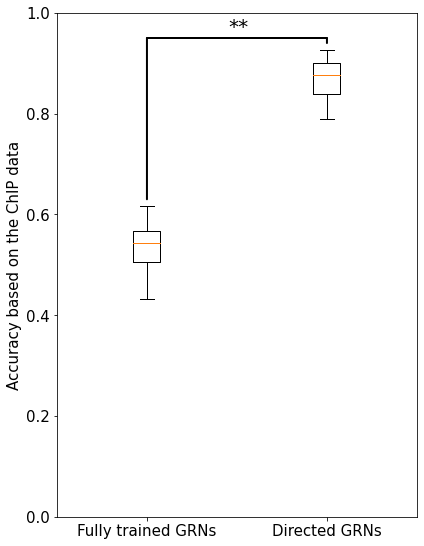

Ttest_indResult(statistic=-28.684521338980094, pvalue=5.8963274370988286e-36)


In [117]:
import matplotlib.pyplot as plt
from scipy import stats
TotalNumberOfGenes = 9

path_NoChIP = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans_New/All_No_ChIP/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)
path_ChIP = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/EGRN_Scipy/Beta_CandidaAlbicans_New/All_ChIP_1.5/BetaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

def GetDistribution(path_):
    infile = open(path_, 'r')
    ContentList = []
    for line in infile:
        ContentList.append(line.split()[1])

    NewList = []
    for i in range(0, len(ContentList)):
        string2append = ''
        for each in ContentList[i]:
            if each == '2':
                string2append = string2append + '1'
            else:
                string2append = string2append + each
        NewList.append(string2append)

    AccDistribution = []
    for each in NewList:
        AccDistribution.append((81-GetHammingDistance_LG(LogicGatesString2Matrix(each), LogicGatesString2Matrix('111111100111111100101100000111111100111010100111011000011100100111110100000000000')))/81)
    return AccDistribution


fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 0.5, 1])
data = [GetDistribution(path_NoChIP), GetDistribution(path_ChIP)]
ax.boxplot(data)
locs, labels = plt.xticks()
plt.xticks([1,2], ['Fully trained GRNs', 'Directed GRNs'], rotation=0, fontsize=15)
plt.yticks(fontsize=15)
ax = plt.gca()
ax.set_ylim([0, 1])

props = {'arrowstyle':'-','shrinkA':0,'shrinkB':0,'linewidth':2}
ax.annotate('**', xy=(1.45,0.96), fontsize=20)
ax.annotate('', xy=(1,0.63), xytext=(1,0.95), arrowprops=props)
ax.annotate('', xy=(2,0.94), xytext=(2,0.95), arrowprops=props)
ax.annotate('', xy=(1,0.95), xytext=(2,0.95), arrowprops=props)
    
plt.ylabel('Accuracy based on the ChIP data', fontsize=15)
plt.show()
print(stats.ttest_ind(GetDistribution(path_NoChIP), GetDistribution(path_ChIP)))

array([0, 1, 2, 3])

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import numpy as np

ChIP_consensus = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,0,1,1,0,1,0,0,1,1,1,1,0,1,0,1,1,1,1,0,1,1,0,0,1,1,1,0,0,1] #All_2
#ChIP_consensus = [1,0,1,1,0,0,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0] #All_3
#ChIP_consensus = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,1,1,0,0,1,0,1,1,0,1] #WhiteOnly
#ChIP_consensus = [1,0,1,0,0,0,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0] #Opaque_3
#ChIP_consensus = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0] #Opaque_2


#Conf_consensus = [1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1] #All
#Conf_consensus = [1,1,0,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,1,0,1,1,0,1,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,1] #WhiteOnly
#Conf_consensus = [0,1,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1,1,1,1,0,0,1,1,0,1,1,1,1,0,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0] #OpaqueOnly
#Conf_consensus = [1,0,1,0,1,1,0,1,1,1,0,1,0,1,0,0,1,1,1,1,0,1,1,0,0,0,1,1,0,1,1,1,1,1,0,1,0,0,0,1,0,0,0,0,1,1,0,1,1] #Top1
Conf_consensus = [1,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,0,1,1,1,0,0,1,1,0,0,1,1,1,0,0,1] #ChIP
#Conf_consensus = [1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,1,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,1] #ChIP_White
#Conf_consensus = [1,0,1,0,1,1,1,1,1,0,0,1,1,1,0,0,1,1,0,0,0,0,1,0,1,0,0,1,1,1,1,0,1,0,1,1,0,0,0,1,1,0,0,0,1,1,0,0,1] #ChIP_Opaque

print(classification_report(ChIP_consensus, Conf_consensus, labels=[0, 1]))
print('Accuracy Score: {}%'.format(100*accuracy_score(ChIP_consensus, Conf_consensus)))
print('Accuracy_control: {}\t'.format((ChIP_consensus.count(0)/3+2*(ChIP_consensus.count(1)/3))/(len(ChIP_consensus))), 'precision_control: {}\t'.format((ChIP_consensus.count(1)**2+ChIP_consensus.count(0)**2)/(len(ChIP_consensus)**2)), 'recall_control: {}'.format((ChIP_consensus.count(0)/3+2*(ChIP_consensus.count(1)/3))/(len(ChIP_consensus))))   

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt


True_Label = [ConfigurationTo012(ReferenceConfiguration)[z] for z in range(0, len(ConfigurationTo012(ReferenceConfiguration)))]
Predicted_Label = [AlphaTestResultCheck(path,-1,30)[z] for z in range(0, len(AlphaTestResultCheck(path,-1,30)))]
#print(Predicted_Label)
'''Control Group'''
'''
RandomStringList = np.random.randint(3,size = (1, TotalNumberOfGenes**2))[0]
RandomString = ''
for INT in RandomStringList:
    RandomString = RandomString + str(INT)
Predicted_Label = [RandomString[z] for z in range(0, len(RandomString))]
'''
#print(True_Label)
#print(Predicted_Label)
fig = plt.figure(figsize=(10,10))
Confusion_Matrix = confusion_matrix(True_Label, Predicted_Label)
sn.heatmap(Confusion_Matrix, annot=True, cmap="Blues", cbar = False, annot_kws={"size":20})
plt.ylabel('True Label', fontsize = 23)
plt.xlabel('Predicted Label', fontsize = 23)
plt.title('Result of GRN{}'.format(TotalNumberOfGenes), fontsize = 23)
plt.xticks(0.5+np.arange(3), ['0', '1', '-1'], fontsize = 15)
plt.yticks(0.5+np.arange(3), ['0', '1', '-1'], fontsize = 15)
plt.show()

target_names = ['0', '1', '-1']

print(classification_report(True_Label, Predicted_Label, target_names=target_names))
#print(classification_report(True_Label, Predicted_Label, target_names=target_names).split()[-4])
print('Accuracy Score: {}%'.format(100*accuracy_score(True_Label, Predicted_Label)))


Precision_List = []
Recall_List = []
for i in range(1, 7):
    LineNum = 5*i
    Predicted_Label = [AlphaTestResultCheck(path,-1,LineNum)[z] for z in range(0, len(AlphaTestResultCheck(path,-1,LineNum)))]
    Confusion_Matrix = confusion_matrix(True_Label, Predicted_Label)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt


True_Label = [Matrix2String01_LG(ReferenceLogicGates)[z] for z in range(0, len(Matrix2String01_LG(ReferenceLogicGates)))]
Predicted_Label = [AlphaTestResultCheck_LG_New(path,-1)[z] for z in range(0, len(AlphaTestResultCheck_LG_New(path,-1)))]
#print(Predicted_Label)
'''Control Group'''
'''
RandomStringList = np.random.randint(3,size = (1, TotalNumberOfGenes**2))[0]
RandomString = ''
for INT in RandomStringList:
    RandomString = RandomString + str(INT)
Predicted_Label = [RandomString[z] for z in range(0, len(RandomString))]
'''
#print(True_Label)
#print(Predicted_Label)
fig = plt.figure(figsize=(10,10))
Confusion_Matrix = confusion_matrix(True_Label, Predicted_Label)
sn.heatmap(Confusion_Matrix, annot=True, cmap="Blues", cbar = False, annot_kws={"size":20})
plt.ylabel('True Label', fontsize = 23)
plt.xlabel('Predicted Label', fontsize = 23)
plt.title('Result of GRN{}'.format(TotalNumberOfGenes), fontsize = 23)
plt.xticks(0.5+np.arange(2), ['0', '1'], fontsize = 15)
plt.yticks(0.5+np.arange(2), ['0', '1'], fontsize = 15)
plt.show()

target_names = ['0', '1']

print(classification_report(True_Label, Predicted_Label, target_names=target_names))
#print(classification_report(True_Label, Predicted_Label, target_names=target_names).split()[-4])
print('Accuracy Score: {}%'.format(100*accuracy_score(True_Label, Predicted_Label)))


Precision_List = []
Recall_List = []
for i in range(1, 7):
    LineNum = 5*i
    Predicted_Label = [AlphaTestResultCheck_LG_New(path,-1)[z] for z in range(0, len(AlphaTestResultCheck_LG_New(path,-1)))]
    Confusion_Matrix = confusion_matrix(True_Label, Predicted_Label)
print(Predicted_Label)
print(True_Label)

In [ ]:
#TotalNumberOfGenes = 5
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '100001001000010200001200001000100000010000000000000000000000100000020010001002000	101010101010101010101010101010101010	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'


ReferenceConfiguration, ReferenceLogicGates, WTTP = GetConfigurationAndWTTP(TargetString)
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])

Toplot = []
for i in range(0, 2*TotalNumberOfGenes**2):
    Toplot.append(GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes,i,ReferenceConfiguration))

import matplotlib.pyplot as plt 
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
fig = plt.figure(figsize=(15,15))
plt.bar(range(len(Toplot)), Toplot)
plt.axvline(x=np.mean(Ave_HC),ls='--',lw = 5,c='red',label='Result Percentile: {}%'.format(round(np.mean(Percentile_HC),15)))
plt.axvline(x=sum_HD_C,ls='--',lw = 5,c='black',label='Control Percentile: {}%'.format(savepercentile))
#plt.xlabel('Hamming distance between the mutant GRN architectures and the reference one', fontsize = 15)
#plt.ylabel('Number of possible GRN architectures', fontsize = 15)
#plt.title('{}-Gene Network Distribution on Hamming Distance'.format(TotalNumberOfGenes), fontsize = 20)
#plt.title('Mutant GRN  Distribution on Hamming Distance', fontsize = 20)
plt.legend(prop=dict(size=23))
plt.show()


In [ ]:
from matplotlib import pyplot as plt

def GetResultFlowData(resultflowpath):
    inputfile = open(resultflowpath,'r')
    HTotal_List = []
    A_List = []
    for line in inputfile:
        line_splited = line.split()
        HTotal_List.append(int(line_splited[4])+int(line_splited[5]))
        A_List.append(float(line_splited[6]))
    return HTotal_List, A_List

GNum = 9
fig = plt.figure(figsize=(10,10))

for CounterNum in range(1,31):
    #print(CounterNum)
    #ResultFlowPath = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/AlphaTestCompleteResults/EGRN_AlphaTest_Complete_G{}_ResultFlow_{}.txt'.format(GNum, CounterNum)
    #ResultFlowPath = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/EGRN_BetaTest_Complete_G6_ResultFlow_{}.txt'.format(CounterNum)
    ResultFlowPath = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/AlphaTestCompleteResults/EGRN_AlphaTest_Complete_G{}_Noise_ResultFlow_{}.txt'.format(GNum, CounterNum)
    Hamming_List, Attractor_List = GetResultFlowData(ResultFlowPath)
    plt.plot([i for i in range(0, 801)], Attractor_List, c='black')
#plt.plot([i for i in range(0, 801)], Hamming_List, c='r')
plt.axis([0,800,0,2])
plt.xlabel('Iterations')
plt.ylabel('Attractor Distance')
plt.title('Training Curve in the 5-gene simulated network with noise')
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib import pyplot as plt
from itertools import cycle
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from scipy import interp


def ROC_Curve(path_, TotalNumberOfGenes_, WhichToView, TargetString_):
    # Just take the highest frequent configuration value
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    y_score = []
    for i in range(0, TotalNumberOfGenes_**2):
        y_score.append(FrequencyDic[str(i)][WhichToView]/sum(FrequencyDic[str(i)]))
    y_true = []
    for i in range(0, len(TargetString_.split()[0])):
        if str(WhichToView) == TargetString_.split()[0][i]:
            y_true.append(1)
        else:
            y_true.append(0)
    return y_score, y_true


TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '100001001000010200001200001000100000010000000000000000000000100000020010001002000	101010101010101010101010101010101010	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/AlphaTestCompleteResults/EGRN_AlphaTest_Complete_G{}_Result.txt'.format(TotalNumberOfGenes)
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/EGRN_BetaTest_Complete_G6_Scrambled_Result.txt'
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/_BetaTest_G6_Result.txt'
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_ChIP/Bayesian_Beta_Result_2020.txt'
path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/EGRN_BetaTest_Complete_G6_Result.txt'

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])



'''Plot ROC Curve'''
lw=2
plt.figure(figsize=(10,10))
plt.plot(fpr["micro"], tpr["micro"],label='micro-average ROC curve (area = {0:0.2f})'''.format(roc_auc["micro"]),color='gold', linewidth=4)
#plt.plot(fpr["macro"], tpr["macro"],label='macro-average ROC curve (area = {0:0.2f})'''.format(roc_auc["macro"]),color='navy', linestyle=':', linewidth=4)
#colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
#for i, color in zip(range(3), colors):
#    plt.plot(fpr[i], tpr[i], color=color, lw=lw,label='ROC curve of class {0} (area = {1:0.2f})'''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve for the Real Network Test')
plt.legend(loc="lower right", prop=dict(size=15))
plt.show()


'''Plot PR Curve'''
lw=3
labels = []
lines = []
plt.figure(figsize=(10,10))
l, = plt.plot(recall["micro"], precision["micro"], color='gold', lw=lw)
lines.append(l)
labels.append('micro-average Precision-recall (area = {0:0.2f})'''.format(average_precision["micro"]))

#for i, color in zip(range(3), colors):
#    l, = plt.plot(recall[i], precision[i], color=color, lw=lw)
#    lines.append(l)
#    labels.append('Precision-recall for class {0} (area = {1:0.2f})'''.format(i, average_precision[i]))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for the Real Network Test')
plt.legend(lines, labels, loc=3, prop=dict(size=15))
plt.show()

In [ ]:
print(y_true_total_list, y_score_total_list)

In [ ]:
from itertools import combinations
import numpy as np

def String012ToMatrix(List012):
    # String '012' to Matrix
    SQRTLEN = int(np.sqrt(len(List012)))
    OutMatrix = np.random.randint(8,9,(2, SQRTLEN, SQRTLEN))
    for i in range(0, len(List012)):
        if List012[i] == '0':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 0
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 0
        elif List012[i] == '1':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 1
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 0
        elif List012[i] == '2':
            OutMatrix[0][i//SQRTLEN][i%SQRTLEN] = 0
            OutMatrix[1][i//SQRTLEN][i%SQRTLEN] = 1
        else:
            raise Exception('List012 must just have 012!\n{}'.format(List012))
    return OutMatrix

def GetCorespondingMatrix_LG(List01):
    SQRTLEN = int(len(List01)/4)
    OutMatrix = np.random.randint(8,9,(SQRTLEN, 4))
    for i in range(0, len(List01)):
        OutMatrix[i//4][i%4] = int(List01[i])
    return OutMatrix

def GetConfigurationAndWTTP(TargetString):
    OutMatrix = String012ToMatrix(TargetString.split()[0])
    OutMatrix_LG = GetCorespondingMatrix_LG(TargetString.split()[1])
    New_String = TargetString.split()[2].split(';')
    WTTP = []
    for i in range(0, len(New_String)):
        if len(New_String[i]) != 0:
            Temp_List = []
            for j in range(0, len(New_String[i].split(','))):
                Temp_List.append(int(New_String[i].split(',')[j]))
            WTTP.append(Temp_List)
        else:
            pass
    WTTP = np.array(WTTP)
    return OutMatrix, OutMatrix_LG, WTTP

def GetDistance(mRNA, WT_mRNA, transcriptionalprofilemax):
    '''Reads are equal'''
    #return(np.linalg.norm(self.mRNA - WT_mRNA))
    '''Genes are equal'''
    outdistance = 0.0
    for y in range(0, len(WT_mRNA)):
        outdistance = outdistance + ((mRNA[y]-WT_mRNA[y])/transcriptionalprofilemax[y])**2
    return np.sqrt(outdistance)



def GetAttractorsQuality(TargetString, NumberofAttractors):
    TestMatrix = (GetConfigurationAndWTTP(TargetString)[2])
    MinList = []
    AveList = []
    StoreList = []
    print(TestMatrix.shape)
    for c in combinations(TestMatrix, NumberofAttractors):
        Distance_Matrix = []
        StoreList.append(c)
        for i in range(0, len(c)):
            for j in range(0, len(c)):
                if i != j:
                    Distance_Matrix.append(GetDistance(c[i], c[j], np.max(TestMatrix, axis=0)))
                else:
                    pass
        Distance_Matrix = np.unique(np.array(Distance_Matrix))
        MinList.append(np.min(Distance_Matrix))
        AveList.append(np.mean(Distance_Matrix))

    # find the max 5 guys in the minlist, then find the one with the max average.
    indlist = []
    for i in range(0, len(MinList)):
        if abs(MinList[i]-np.max(MinList)) <= 0.005:
            indlist.append(i)
        else:
            pass
    avelist2 = []
    for j in range(0, len(indlist)):
        avelist2.append(AveList[indlist[j]])
    finalind = indlist[avelist2.index(max(avelist2))]
    return (MinList[finalind], AveList[finalind], StoreList[finalind])

def output_function(MinTag, AveTag, ConfigurationString, LogicGatesString, Arrays):
    outfile = open('/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/ConfigurationAttractors/TempTest_Configuration_LogicGate_Attractors_G5.txt', 'a')      
    outfile.write('{}_{}\t'.format(MinTag, AveTag))
    outfile.write(ConfigurationString)
    outfile.write('\t')
    outfile.write(LogicGatesString)
    outfile.write('\t')
    MatrixCollector = Arrays
    for i in range(0, len(MatrixCollector)):
        for j in range(0, len(MatrixCollector[i])):
            outfile.write(str(MatrixCollector[i][j]))
            if j == len(MatrixCollector[i])-1:
                pass
            else:
                outfile.write(',')
        outfile.write(';')
    outfile.write('\n')
    outfile.close()
    return

inputfile = open('/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/ConfigurationAttractors/Configuration_LogicGate_Attractors_PowerLaw_G8.txt', 'r')
for line in inputfile:
    line_splited = line.split('\n')[0]
    line_splited_Configuration = line_splited.split()[0]
    line_splited_LogicGate = line_splited.split()[1]
    print(len(GetConfigurationAndWTTP(line_splited)[2]))
    #if len(GetConfigurationAndWTTP(line_splited)[2]) <= 25:
    #    mintag_, avetag_, arrays_ = GetAttractorsQuality(line_splited, 10)
    #    output_function(mintag_, avetag_, line_splited_Configuration, line_splited_LogicGate, arrays_)
    #else:
    #    pass
inputfile.close()





In [ ]:
accu = []
f1 = []
rec = []
prec = []
for xz in range(0, 10000):
    RandomStringList = np.random.randint(3,size = (1, TotalNumberOfGenes**2))[0]
    RandomString = ''
    for INT in RandomStringList:
        RandomString = RandomString + str(INT)
    Predicted_Label = [RandomString[z] for z in range(0, len(RandomString))]
    accu.append(accuracy_score(True_Label, Predicted_Label)*100)
    f1.append(float(classification_report(True_Label, Predicted_Label, target_names=target_names).split()[-2]))
    rec.append(float(classification_report(True_Label, Predicted_Label, target_names=target_names).split()[-3]))
    prec.append(float(classification_report(True_Label, Predicted_Label, target_names=target_names).split()[-4]))
accu = np.array(accu)
f1 = np.array(f1)
rec = np.array(rec)
prec = np.array(prec)
print(np.mean(accu))
print(np.mean(f1))
print(np.mean(rec))
print(np.mean(prec))

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib import pyplot as plt
from itertools import cycle
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from scipy import interp

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()

TargetString_Beta = '100100010010001100000010000001000000	001000100010001000100010	19,23,594,13,0,0;'
Model_Name = ['ARACNE', 'PCIT', 'CLR', 'GENIE3', 'ZSCORE', 'MUTRANK', 'MRNET', 'ScanBMA', 'SIMONE']
color_Name = ['blue', 'purple', 'pink', 'orange', 'red', 'green', 'brown', 'grey', 'black']

def BenchmarkModels_01(modelname, col):
    y_true = []
    for i in range(0, len(TargetString_Beta.split()[0])):
        y_true.append(int(TargetString_Beta.split()[0][i]))

    y_score = []
    i_file = open('/Users/ruihaoli/Desktop/{}_Network_TS.txt'.format(modelname),'r')
    for line in i_file:
        for j in range(0, len(line.split())):
            y_score.append(float(line.split()[j]))
    if max(y_score) > 1.0:
        for i in range(0, len(y_score)):
            y_score[i] = y_score[i]/max(y_score)
    else:
        pass

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true, y_score)
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"],label='{} (area = {})'.format(modelname, round(roc_auc["micro"],2)),color=col, linewidth=4)
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true,y_score)
    average_precision["micro"] = average_precision_score(y_true, y_score, average="micro")

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    

    #lw=3
    #labels = []
    #lines = []
    #plt.figure(figsize=(10,10))
    #l, = plt.plot(recall["micro"], precision["micro"], color='black', lw=lw)
    #lines.append(l)
    #labels.append('micro-average Precision-recall (area = {0:0.2f})'''.format(average_precision["micro"]))

    #plt.xlim([0.0, 1.0])
    #plt.ylim([0.0, 1.05])
    #plt.xlabel('Recall')
    #plt.ylabel('Precision')
    #plt.title('Precision-Recall curve for the Real Network Test by {}'.format(modelname))
    #plt.legend(lines, labels, loc=3, prop=dict(size=15))
    #plt.show()

    return

def BenchmarkModels_012(modelname, col):
    y_true = [1,0,0,2,0,0,0,1,0,0,2,0,0,0,1,2,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0,0]

    y_score = []
    i_file = open('/Users/ruihaoli/Desktop/{}_Network_TS.txt'.format(modelname),'r')
    for line in i_file:
        for j in range(0, len(line.split())):
            y_score.append(float(line.split()[j]))
    
    y_true_total = []
    y_score_total = []
    for which in [0,1,2]:
        for len_ in range(0, len(y_true)):
            if y_true[len_] == which:
                y_true_total.append(1)
            else:
                y_true_total.append(0)
            if which == 0:
                if y_score[len_] >0:
                     y_score_total.append(1-y_score[len_])
                elif y_score[len_] ==0:
                     y_score_total.append(1)
                elif y_score[len_] <0:
                     y_score_total.append(1-abs(y_score[len_]))
                else:
                    pass
            elif which == 1:
                if y_score[len_] >0:
                     y_score_total.append(y_score[len_])
                elif y_score[len_] ==0:
                     y_score_total.append(0)
                elif y_score[len_] <0: # cuode
                    if y_true[len_] == 1:
                        y_score_total.append(0)
                    elif y_true[len_] == 0:
                        y_score_total.append(1)
                    elif y_true[len_] == 2:
                        y_score_total.append(1)
                    else:
                        pass
                else:
                    pass
            else:
                if y_score[len_] >0: # cuode
                    if y_true[len_] == 2:
                        y_score_total.append(0)
                    elif y_true[len_] == 1:
                        y_score_total.append(1)
                    elif y_true[len_] == 0:
                        y_score_total.append(1)
                    else:
                        pass
                elif y_score[len_] ==0:
                     y_score_total.append(0)
                elif y_score[len_] <0:
                    y_score_total.append(abs(y_score[len_]))
                else:
                    pass
    
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total, y_score_total)
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    lw=2
    plt.plot(fpr["micro"], tpr["micro"],label='{} (AUC = {})'.format(modelname, round(roc_auc["micro"],3)),color=col, linewidth=4)
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total,y_score_total)
    average_precision["micro"] = average_precision_score(y_true_total, y_score_total, average="micro")

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    #lw=3
    #labels = []
    #lines = []
    #plt.figure(figsize=(10,10))
    #l, = plt.plot(recall["micro"], precision["micro"], color='black', lw=lw)
    #lines.append(l)
    #labels.append('micro-average Precision-recall (area = {0:0.2f})'''.format(average_precision["micro"]))

    #plt.xlim([0.0, 1.0])
    #plt.ylim([0.0, 1.05])
    #plt.xlabel('Recall')
    #plt.ylabel('Precision')
    #plt.title('Precision-Recall curve for the Real Network Test by {}'.format(modelname))
    #plt.legend(lines, labels, loc=3, prop=dict(size=15))
    #plt.show()
    return

#for xxx in range(0, len(Model_Name)):
#    BenchmarkModels(Model_Name[xxx])

lw=2
plt.figure(figsize=(10,10))

for xia in range(0, len(Model_Name)-1):
    BenchmarkModels_01(Model_Name[xia], color_Name[xia])
BenchmarkModels_012('SIMONE', color_Name[-1])





def ROC_Curve(path_, TotalNumberOfGenes_, WhichToView, TargetString_):
    # Just take the highest frequent configuration value
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    y_score = []
    for i in range(0, TotalNumberOfGenes_**2):
        y_score.append(FrequencyDic[str(i)][WhichToView]/sum(FrequencyDic[str(i)]))
    y_true = []
    for i in range(0, len(TargetString_.split()[0])):
        if str(WhichToView) == TargetString_.split()[0][i]:
            y_true.append(1)
        else:
            y_true.append(0)
    return y_score, y_true


TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '100001001000010200001200001000100000010000000000000000000000100000020010001002000	101010101010101010101010101010101010	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/AlphaTestCompleteResults/EGRN_AlphaTest_Complete_G{}_Result.txt'.format(TotalNumberOfGenes)
path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/EGRN_BetaTest_Complete_G6_Result.txt'
path = '/Users/ruihaoli/Desktop/BetaTest_G6_Result_1.txt'

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])



'''Plot ROC Curve'''
lw=2
#plt.figure(figsize=(10,10))
plt.plot(fpr["micro"], tpr["micro"],label='My Model (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='gold', linewidth=4, ls='--')
#plt.plot(fpr["macro"], tpr["macro"],label='macro-average ROC curve (area = {0:0.2f})'''.format(roc_auc["macro"]),color='navy', linestyle=':', linewidth=4)
#colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
#for i, color in zip(range(3), colors):
#    plt.plot(fpr[i], tpr[i], color=color, lw=lw,label='ROC curve of class {0} (area = {1:0.2f})'''.format(i, roc_auc[i]))



#'''Plot PR Curve'''
#lw=3
#labels = []
#lines = []
#plt.figure(figsize=(10,10))
#l, = plt.plot(recall["micro"], precision["micro"], color='black', lw=lw)
#lines.append(l)
#labels.append('micro-average Precision-recall (area = {0:0.2f})'''.format(average_precision["micro"]))















plt.xlabel('False Positive Rate',  fontsize = 25)
plt.ylabel('True Positive Rate',  fontsize = 25)
#plt.title('Receiver Operating Characteristic Curve', fontsize = 15)
plt.legend(loc="upper left", prop=dict(size=11))
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib import pyplot as plt
from itertools import cycle
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from scipy import interp

TargetString_Beta = '100100010010001100000010000001000000	001000100010001000100010	19,23,594,13,0,0;'
Model_Name = ['ARACNE', 'PCIT', 'CLR', 'GENIE3', 'ZSCORE', 'MUTRANK', 'MRNET', 'ScanBMA', 'SIMONE']
color_Name = ['blue', 'purple', 'pink', 'orange', 'red', 'green', 'brown', 'grey', 'black']

def BenchmarkModels_01(modelname, col):
    y_true = []
    for i in range(0, len(TargetString_Beta.split()[0])):
        y_true.append(int(TargetString_Beta.split()[0][i]))

    y_score = []
    i_file = open('/Users/ruihaoli/Desktop/{}_Network_TS.txt'.format(modelname),'r')
    for line in i_file:
        for j in range(0, len(line.split())):
            y_score.append(float(line.split()[j]))
    if max(y_score) > 1.0:
        for i in range(0, len(y_score)):
            y_score[i] = y_score[i]/max(y_score)
    else:
        pass

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true, y_score)
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true,y_score)
    average_precision["micro"] = average_precision_score(y_true, y_score, average="micro")

    l, = plt.plot(recall["micro"], precision["micro"], color=col, lw=lw)
    lines.append(l)
    labels.append('{} (AUC = {})'.format(modelname, round(average_precision["micro"],2)))
    return



def BenchmarkModels_012(modelname, col):
    y_true = [1,0,0,2,0,0,0,1,0,0,2,0,0,0,1,2,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0,0]

    y_score = []
    i_file = open('/Users/ruihaoli/Desktop/{}_Network_TS.txt'.format(modelname),'r')
    for line in i_file:
        for j in range(0, len(line.split())):
            y_score.append(float(line.split()[j]))
    
    y_true_total = []
    y_score_total = []
    for which in [0,1,2]:
        for len_ in range(0, len(y_true)):
            if y_true[len_] == which:
                y_true_total.append(1)
            else:
                y_true_total.append(0)
            if which == 0:
                if y_score[len_] >0:
                     y_score_total.append(1-y_score[len_])
                elif y_score[len_] ==0:
                     y_score_total.append(1)
                elif y_score[len_] <0:
                     y_score_total.append(1-abs(y_score[len_]))
                else:
                    pass
            elif which == 1:
                if y_score[len_] >0:
                     y_score_total.append(y_score[len_])
                elif y_score[len_] ==0:
                     y_score_total.append(0)
                elif y_score[len_] <0: # cuode
                    if y_true[len_] == 1:
                        y_score_total.append(0)
                    elif y_true[len_] == 0:
                        y_score_total.append(1)
                    elif y_true[len_] == 2:
                        y_score_total.append(1)
                    else:
                        pass
                else:
                    pass
            else:
                if y_score[len_] >0: # cuode
                    if y_true[len_] == 2:
                        y_score_total.append(0)
                    elif y_true[len_] == 1:
                        y_score_total.append(1)
                    elif y_true[len_] == 0:
                        y_score_total.append(1)
                    else:
                        pass
                elif y_score[len_] ==0:
                     y_score_total.append(0)
                elif y_score[len_] <0:
                    y_score_total.append(abs(y_score[len_]))
                else:
                    pass
    
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total, y_score_total)
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


    l, = plt.plot(recall["micro"], precision["micro"], color='black', lw=lw)
    lines.append(l)
    labels.append('{} (AUC = {})'.format(modelname, round(average_precision["micro"],2)))


    return

#for xxx in range(0, len(Model_Name)):
#    BenchmarkModels(Model_Name[xxx])

lw=3
labels = []
lines = []
plt.figure(figsize=(10,10))


for xia in range(0, len(Model_Name)-1):
    BenchmarkModels_01(Model_Name[xia], color_Name[xia])
BenchmarkModels_012('SIMONE', color_Name[-1])





def ROC_Curve(path_, TotalNumberOfGenes_, WhichToView, TargetString_):
    # Just take the highest frequent configuration value
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    y_score = []
    for i in range(0, TotalNumberOfGenes_**2):
        y_score.append(FrequencyDic[str(i)][WhichToView]/sum(FrequencyDic[str(i)]))
    y_true = []
    for i in range(0, len(TargetString_.split()[0])):
        if str(WhichToView) == TargetString_.split()[0][i]:
            y_true.append(1)
        else:
            y_true.append(0)
    return y_score, y_true


TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '100001001000010200001200001000100000010000000000000000000000100000020010001002000	101010101010101010101010101010101010	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
#path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Alpha_Test_Complete/AlphaTestCompleteResults/EGRN_AlphaTest_Complete_G{}_Result.txt'.format(TotalNumberOfGenes)
path = '/Users/ruihaoli/Desktop/EvolutionaryGeneRegulatoryNetworkModel/Beta_Test_Complete/Results/EGRN_BetaTest_Complete_G6_Result.txt'
path = '/Users/ruihaoli/Desktop/BetaTest_G6_Result.txt'

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])






'''Plot PR Curve'''

l, = plt.plot(recall["micro"], precision["micro"], color='gold', lw=lw, ls = '--')
lines.append(l)
labels.append('My model (AUC = {0:0.2f})'''.format(average_precision["micro"]))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize = 25)
plt.ylabel('Precision', fontsize = 25)
#plt.title('Precision-Recall curve', fontsize = 15)
plt.legend(lines, labels, loc='upper right', prop=dict(size=11))
plt.show()

In [ ]:
TotalNumberOfGenes = 9
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '100001001000010200001200001000100000010000000000000000000000100000020010001002000	101010101010101010101010101010101010	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'

outfile = open('/Users/ruihaoli/Desktop/aaa1212.txt', 'a')


#print(TargetString.split()[2].split(';'))


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib import pyplot as plt
from itertools import cycle
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from scipy import interp


def ROC_Curve(path_, TotalNumberOfGenes_, WhichToView, TargetString_):
    # Just take the highest frequent configuration value
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    y_score = []
    for i in range(0, TotalNumberOfGenes_**2):
        y_score.append(FrequencyDic[str(i)][WhichToView]/sum(FrequencyDic[str(i)]))
    y_true = []
    for i in range(0, len(TargetString_.split()[0])):
        if str(WhichToView) == TargetString_.split()[0][i]:
            y_true.append(1)
        else:
            y_true.append(0)
    return y_score, y_true


TotalNumberOfGenes = 5
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)


fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])



'''Plot ROC Curve'''

lw=2
plt.figure(figsize=(10,10))
plt.plot(fpr["micro"], tpr["micro"],label='5-gene GRN (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='blue', linewidth=4)





TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
plt.plot(fpr["micro"], tpr["micro"],label='6-gene GRN (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='orange', linewidth=4)


TotalNumberOfGenes = 7
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3


plt.plot(fpr["micro"], tpr["micro"],label='7-gene GRN (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='purple', linewidth=4)

TotalNumberOfGenes = 8
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)


fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3

plt.plot(fpr["micro"], tpr["micro"],label='8-gene GRN (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='green', linewidth=4)


TotalNumberOfGenes = 9
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3


plt.plot(fpr["micro"], tpr["micro"],label='9-gene GRN (AUC = {0:0.2f})'''.format(roc_auc["micro"]),color='red', linewidth=4)


#for i, color in zip(range(3), colors):
#    l, = plt.plot(recall[i], precision[i], color=color, lw=lw)
#    lines.append(l)
#    labels.append('Precision-recall for class {0} (area = {1:0.2f})'''.format(i, average_precision[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize = 25)
plt.ylabel('True Positive Rate', fontsize = 25)
#plt.title('Receiver Operating Characteristic curve for the in-silico test', fontsize = 15)
plt.legend(loc="lower right", prop=dict(size=18))
plt.tick_params(labelsize=20)
plt.show()




In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib import pyplot as plt
from itertools import cycle
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from scipy import interp


def ROC_Curve(path_, TotalNumberOfGenes_, WhichToView, TargetString_):
    # Just take the highest frequent configuration value
    AlphaTestResultFile = open(path_, 'r')
    ResultConfigurations = []
    for line in AlphaTestResultFile:
        line_splited = line.split()
        ReferenceConfiguration = line_splited[0]
        ResultConfigurations.append(line_splited[1])
    AlphaTestResultFile.close()
    FrequencyDic = {}
    for i in range(0, len(ResultConfigurations[0])):
        FrequencyDic[str(i)] = [0,0,0]
    for i in range(0, len(ResultConfigurations)):
        for j in range(0, len(ResultConfigurations[i])):
            FrequencyDic[str(j)][int(ResultConfigurations[i][j])] = FrequencyDic[str(j)][int(ResultConfigurations[i][j])] + 1
    y_score = []
    for i in range(0, TotalNumberOfGenes_**2):
        y_score.append(FrequencyDic[str(i)][WhichToView]/sum(FrequencyDic[str(i)]))
    y_true = []
    for i in range(0, len(TargetString_.split()[0])):
        if str(WhichToView) == TargetString_.split()[0][i]:
            y_true.append(1)
        else:
            y_true.append(0)
    return y_score, y_true


TotalNumberOfGenes = 5
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])



'''Plot ROC Curve'''

lw=2
plt.figure(figsize=(10,10))
plt.plot(recall["micro"], precision["micro"],label='5-gene GRN (AUC = {0:0.2f})'''.format(average_precision["micro"]),color='blue', linewidth=4)





TotalNumberOfGenes = 6
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
plt.plot(recall["micro"], precision["micro"],label='6-gene GRN (AUC = {0:0.2f})'''.format(average_precision["micro"]),color='orange', linewidth=4)


TotalNumberOfGenes = 7
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3


plt.plot(recall["micro"], precision["micro"],label='7-gene GRN (AUC = {0:0.2f})'''.format(average_precision["micro"]),color='purple', linewidth=4)

TotalNumberOfGenes = 8
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3

plt.plot(recall["micro"], precision["micro"],label='8-gene GRN (AUC = {0:0.2f})'''.format(average_precision["micro"]),color='green', linewidth=4)


TotalNumberOfGenes = 9
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
# BetaTestComplete
#ReferenceConfiguration = np.array([[[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]],[[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,1],[0,0,0,0,0,0]]])
#ReferenceLogicGates = np.array([[1,1,1,0], [1,1,1,0], [1,1,1,0], [1,1,1,1], [1,1,1,1], [1,1,1,1]])
path = 'C:/Users/13234/Desktop/EGRN/AlphaG{}/AlphaTest_G{}_Result.txt'.format(TotalNumberOfGenes,TotalNumberOfGenes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
average_precision = dict()
y_score_total_list = []
y_true_total_list = []
for i in range(0,3):
    y_score_list, y_true_list = ROC_Curve(path,TotalNumberOfGenes,i, TargetString)
    y_score_total_list.append(y_score_list)
    y_true_total_list.append(y_true_list)
    fpr[i], tpr[i], _ = roc_curve(y_true_list, y_score_list)
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_list, y_score_list)
    average_precision[i] = average_precision_score(y_true_list, y_score_list)
y_score_total_list = np.array(y_score_total_list)
y_true_total_list = np.array(y_true_total_list)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_total_list.ravel(), y_score_total_list.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_total_list.ravel(),y_score_total_list.ravel())
average_precision["micro"] = average_precision_score(y_true_total_list, y_score_total_list, average="micro")
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


'''Plot ROC Curve'''
lw=3


plt.plot(recall["micro"], precision["micro"], label='9-gene GRN (AUC = {0:0.2f})'''.format(average_precision["micro"]),color='red', linewidth=4)


#for i, color in zip(range(3), colors):
#    l, = plt.plot(recall[i], precision[i], color=color, lw=lw)
#    lines.append(l)
#    labels.append('Precision-recall for class {0} (area = {1:0.2f})'''.format(i, average_precision[i]))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize = 25)
plt.ylabel('Precision', fontsize = 25)
#plt.title('Precision-Recall curve for the in-silico test', fontsize = 15)
plt.legend(loc="lower right", prop=dict(size=18))
plt.tick_params(labelsize=20)
plt.show()




In [ ]:
import math
TotalNumberOfGenes = 9
if TotalNumberOfGenes == 5:
    TargetString = '1200101000001000021010000	10101010101010101010	19,2370,593,11,40;19,492,2852,11,40;19,492,29,1303,40;1922,24,29,1303,4055;1922,24,2852,11,4055;19,492,593,11,40;19,2370,29,1303,40;1922,24,593,11,4055;19,2370,2852,11,40;'
elif TotalNumberOfGenes == 6:
    TargetString = '000000112000001001000120000010000000	001000100010001000100010	19,23,594,1303,42,29;19,23,2852,11,843,2978;19,23,2852,11,4055,2978;1924,2372,29,11,843,29;1924,2372,29,11,4055,29;19,23,594,11,4055,29;1924,2372,29,1303,42,29;19,23,2852,1303,42,2978;19,23,594,11,843,29;'
elif TotalNumberOfGenes == 7:
    TargetString = '0000000000000001102002001021000010010000100001001	0010001000100010001000100010	20,23,27,1305,4055,31,3733;400,2370,2852,11,42,619,35;20,2370,2852,1305,42,31,3733;1922,23,27,11,843,2978,35;400,23,27,11,4055,619,35;400,23,27,11,843,619,35;1922,23,27,11,4055,2978,35;1922,2370,2852,11,42,2978,35;20,23,27,1305,843,31,3733;'
elif TotalNumberOfGenes == 8:
    TargetString = '1000100001000001001002002000000000000000002001100020000000010001	10101010101010101010101010101010	399,22,27,13,40,2980,3727,28;399,2370,2852,13,40,31,37,28;399,2370,593,13,40,620,37,28;20,2370,593,1303,40,620,37,2804;399,22,593,13,40,620,37,28;399,22,2852,13,40,31,37,28;399,2370,27,13,40,2980,3727,28;1922,22,593,13,4055,620,37,28;20,2370,27,1303,40,2980,3727,2804;'
elif TotalNumberOfGenes == 9:
    TargetString = '120100020000010220101000001220100000210010020120101000200000100020020010001202000	000000000101001100101001000110010100	1924,2370,27,1303,4055,2978,38,26,39;17,2370,27,1303,4055,619,38,26,39;17,2370,28,270,4055,619,38,26,39;1924,23,27,1303,845,2978,3727,26,39;1924,23,2852,13,42,31,775,2803,3896;17,23,28,270,42,619,3727,2803,39;17,23,27,1303,42,619,775,2803,39;1924,23,27,1303,42,2978,3727,2803,39;1924,2370,2852,13,4055,31,38,26,3896;'
ReferenceConfiguration, ReferenceLogicGates, WTTP = GetConfigurationAndWTTP(TargetString)

C_String = TargetString.split('\t')[0]
sum_HD_C = 0
TP = 0
TN = 0
FP = 0
FN = 0
for i in range(0, TotalNumberOfGenes**2):
    if C_String[i] == '0':
        sum_HD_C = sum_HD_C + (1/3)*0 + (1/3)*1 + (1/3)*1
        TP = TP + (1/3)*0 + (1/3)*0 + (1/3)*0
        TN = TN + (1/3)*1 + (1/3)*0 + (1/3)*0
        FP = FP + (1/3)*0 + (1/3)*1 + (1/3)*1
        FN = FN + (1/3)*0 + (1/3)*0 + (1/3)*0
    elif C_String[i] == '1':
        sum_HD_C = sum_HD_C + (1/3)*1 + (1/3)*0 + (1/3)*2
        TP = TP + (1/3)*0 + (1/3)*1 + (1/3)*0
        TN = TN + (1/3)*0 + (1/3)*0 + (1/3)*0
        FP = FP + (1/3)*0 + (1/3)*0 + (1/3)*1
        FN = FN + (1/3)*1 + (1/3)*0 + (1/3)*0
    elif C_String[i] == '2':
        sum_HD_C = sum_HD_C + (1/3)*1 + (1/3)*2 + (1/3)*0  
        TP = TP + (1/3)*0 + (1/3)*0 + (1/3)*1
        TN = TN + (1/3)*0 + (1/3)*0 + (1/3)*0
        FP = FP + (1/3)*0 + (1/3)*1 + (1/3)*0
        FN = FN + (1/3)*1 + (1/3)*0 + (1/3)*0
    else:
        raise Exception('Wrong String')
    
ConfigurationHamming_ = 0
for P in range(0, int(sum_HD_C)+1):
    ConfigurationHamming_ = ConfigurationHamming_ + GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes, P, ReferenceConfiguration)
ConfigurationHamming_ = ConfigurationHamming_ + (sum_HD_C - int(sum_HD_C)) * GetPossibleNetworksGivenHammingDistance(TotalNumberOfGenes, int(sum_HD_C)+1, ReferenceConfiguration)
    
print('Configuration -> Precision_Control: ', np.round(TP/(TP+FP),3), 'Accuracy: ', np.round((TP+TN)/(TP+TN+FP+FN), 3), 'Recall_Control: ', np.round(TP/(TP+FN),3), 'HammingDistance_Control: ', np.round(sum_HD_C,3), 'Percentile_Control: ', round(100*ConfigurationHamming_/C_Total,3), '%')


LG_String = TargetString.split('\t')[1]
sum_HD_LG = 0
TP = 0
TN = 0
FP = 0
FN = 0
for i in range(0, TotalNumberOfGenes*4):
    if LG_String[i] == '0':
        sum_HD_LG = sum_HD_LG + (1/2)*0 + (1/2)*1
        TP = TP + (1/2)*0 + (1/2)*0
        TN = TN + (1/2)*1 + (1/2)*0
        FP = FP + (1/2)*0 + (1/2)*1
        FN = FN + (1/2)*0 + (1/2)*0
    elif LG_String[i] == '1':
        sum_HD_LG = sum_HD_LG + (1/2)*1 + (1/2)*0
        TP = TP + (1/2)*0 + (1/2)*1
        TN = TN + (1/2)*0 + (1/2)*0
        FP = FP + (1/2)*0 + (1/2)*0
        FN = FN + (1/2)*1 + (1/2)*0
    else:
        raise Exception('Wrong String')

LogicGateHamming_ = 0
for j in range(0, int(sum_HD_LG)+1):
    LogicGateHamming_ = LogicGateHamming_ + GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)
LogicGateHamming_ = LogicGateHamming_ + (sum_HD_LG - int(sum_HD_LG)) * GetPossibleNetworksGivenHammingDistance_LG(TotalNumberOfGenes, j)

print('LogicGates -> Precision_Control: ', np.round(TP/(TP+FP),3), 'Accuracy: ', np.round((TP+TN)/(TP+TN+FP+FN), 3), 'Recall_Control: ', np.round(TP/(TP+FN),3), 'HammingDistance_Control: ', np.round(sum_HD_LG,3), 'Percentile_Control: ', round(100*LogicGateHamming_/LG_Total,3), '%')


In [ ]:
np.random.normal(loc=0, scale = 0.2)

In [15]:
import numpy as np
infile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/Random_KOs/random_6.txt', 'r')
Content = []
for line in infile:
    print(line.split())
    Content.append([float(line.split()[0]), float(line.split()[1])])
#print(Content)

Counter = [0,0]
Sum = [0,0]
All = []
for each in Content:
    if each[0] == 45:
        pass
    else:
        Counter[0] = Counter[0] + 1
        Sum[0] = Sum[0] + each[0]
        All.append(each[0])
    if each[1] == 45:
        pass
    else:
        Counter[1] = Counter[1] + 1
        Sum[1] = Sum[1] + each[1]
        All.append(each[1])
Average = [100*Sum[0]/Counter[0], 100*Sum[1]/Counter[1]]
print(np.array(Counter)/10, Average)

['45', '45']
['0.29909575548299394', '45']
['45', '0.2697264164405383']
['0.2991967698275356', '0.4142478964212422']
['0.3345927044540978', '0.26315243314247294']
['0.49160109734440727', '45']
['0.19663656635819773', '0.2578336428602846']
['45', '0.3134498087540761']
['45', '45']
['0.2833901940930928', '0.3445499193013632']
['45', '45']
['45', '0.3290460980563779']
['45', '0.3056372614905433']
['45', '0.239704401337558']
['0.48935104954443176', '45']
['0.29546985530536374', '45']
['0.43281211988810164', '0.38728987816949856']
['0.35829667059853565', '45']
['0.43017797330791185', '0.26831382589438274']
['0.39607607628057323', '0.20912125761949996']
['45', '0.2728304079436611']
['45', '45']
['45', '45']
['0.36492658742196604', '45']
['45', '0.13726368045309376']
['45', '0.411775157839265']
['45', '0.40015021952014324']
['45', '0.3038918972138343']
['45', '45']
['0.2831933095478396', '0.20234410789612597']
['45', '0.32672421400926766']
['45', '0.3642279056475852']
['45', '0.23301920828993

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 7, 12, 23, 32, 45, 61, 78, 99, 121, 139, 161, 193, 225, 270, 316, 361, 409, 454, 503, 559, 605, 639, 676, 714, 766, 796, 825, 851, 882, 903, 930, 948, 964, 981, 1000, 1010, 1019, 1027, 1033, 1035, 1039, 1046, 1051, 1051, 1052, 1053, 1054, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055, 1055]


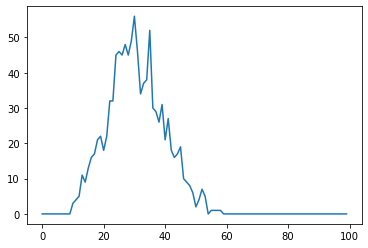

In [16]:
successful_prediction = []
for threshold_ in range(0, 101):
    successful_prediction.append(0)
    for each in All:
        if each <= threshold_*0.01:
            successful_prediction[-1] +=  1
        else:
            pass
print(successful_prediction)

from matplotlib import pyplot as plt

each_prob = []

for i in range(1, 101):
    each_prob.append(successful_prediction[i]-successful_prediction[i-1])

plt.plot(each_prob)

In [4]:
import numpy as np

def MyTest(thresh, num_x, midpoint):
    x = np.array([np.random.uniform(0, 1) for i in range(0, num_x)])
    y = x-midpoint
    mysum = 0
    for each in y:
        mysum = mysum + abs(each)
    if mysum <= thresh*num_x: # successful prediction
        return 1
    else:
        return 0

result_content = []
for threshold_ in range(0, 101):
    recorder = []
    for i in range(0, 10000):
        if i%1000 == 0:
            print(threshold_, '\t', i)
        else:
            pass
        for midp in range(0, 100):
            recorder.append(MyTest(threshold_*0.01, 9, midp*0.01))
    result_content.append(100*sum(recorder)/1000000)
    print(100*sum(recorder)/1000000, '%')

0 	 0
0 	 1000
0 	 2000
0 	 3000
0 	 4000
0 	 5000
0 	 6000
0 	 7000
0 	 8000
0 	 9000
0.0 %
1 	 0
1 	 1000
1 	 2000
1 	 3000
1 	 4000
1 	 5000
1 	 6000
1 	 7000
1 	 8000
1 	 9000
0.0 %
2 	 0
2 	 1000
2 	 2000
2 	 3000
2 	 4000
2 	 5000
2 	 6000
2 	 7000
2 	 8000
2 	 9000
0.0 %
3 	 0
3 	 1000
3 	 2000
3 	 3000
3 	 4000
3 	 5000
3 	 6000
3 	 7000
3 	 8000
3 	 9000
0.0 %
4 	 0
4 	 1000
4 	 2000
4 	 3000
4 	 4000
4 	 5000
4 	 6000
4 	 7000
4 	 8000
4 	 9000
0.0 %
5 	 0
5 	 1000
5 	 2000
5 	 3000
5 	 4000
5 	 5000
5 	 6000
5 	 7000
5 	 8000
5 	 9000
0.0 %
6 	 0
6 	 1000
6 	 2000
6 	 3000
6 	 4000
6 	 5000
6 	 6000
6 	 7000
6 	 8000
6 	 9000
0.0002 %
7 	 0
7 	 1000
7 	 2000
7 	 3000
7 	 4000
7 	 5000
7 	 6000
7 	 7000
7 	 8000
7 	 9000
0.0008 %
8 	 0
8 	 1000
8 	 2000
8 	 3000
8 	 4000
8 	 5000
8 	 6000
8 	 7000
8 	 8000
8 	 9000
0.0034 %
9 	 0
9 	 1000
9 	 2000
9 	 3000
9 	 4000
9 	 5000
9 	 6000
9 	 7000
9 	 8000
9 	 9000
0.0154 %
10 	 0
10 	 1000
10 	 2000
10 	 3000
10 	 4000
10 	 5000
1

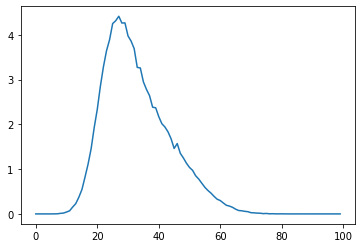

In [5]:
from matplotlib import pyplot as plt

each_prob = []

for i in range(1, 101):
    each_prob.append(result_content[i]-result_content[i-1])

plt.plot(each_prob)
#plt.plot(result_content)

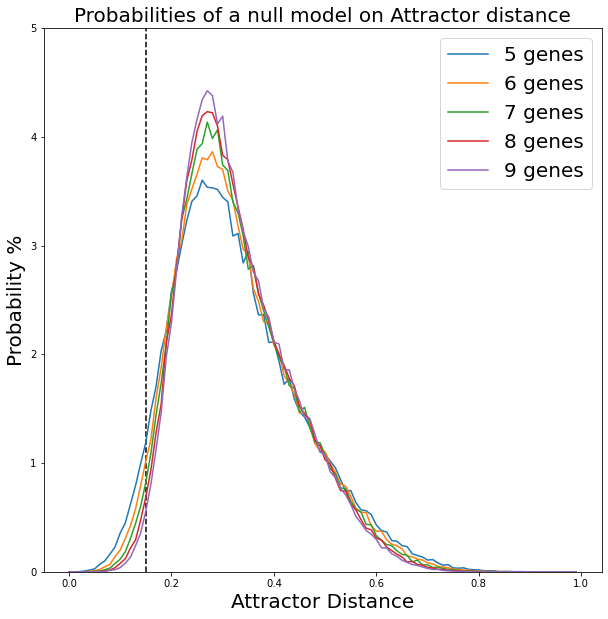

In [8]:
from matplotlib import pyplot as plt

def Readfile(n):
    content = []
    infile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/probs_{}.txt'.format(n), 'r')
    for line in infile:
        content.append(float(line.split()[0]))
    infile.close()
    return content

Content5 = Readfile(5)
Content6 = Readfile(6)
Content7 = Readfile(7)
Content8 = Readfile(8)
Content9 = Readfile(9)

fig = plt.figure(figsize = (10,10))
plt.plot([0.01*i for i in range(0, 100)], Content5, label='5 genes')
plt.plot([0.01*i for i in range(0, 100)], Content6, label='6 genes')
plt.plot([0.01*i for i in range(0, 100)], Content7, label='7 genes')
plt.plot([0.01*i for i in range(0, 100)], Content8, label='8 genes')
plt.plot([0.01*i for i in range(0, 100)], Content9, label='9 genes')
plt.legend(fontsize=20)
plt.xlabel('Attractor Distance', fontsize=20)
plt.ylabel('Probability %', fontsize=20)
plt.ylim([0, 5])
plt.vlines(0.15, 0, 6, linestyles='dashed', colors='black')

plt.title('Probabilities of a null model on Attractor distance', fontsize=20)
plt.show()



In [36]:
import pandas as pd
import numpy as np
import os

def workingthis(target, SampleIndex_fun):
    for each_batch in SampleIndex_fun:
        for i in range(0, len(each_batch)):
            if target[:-4] in each_batch[i] and len(target)>20:
                os.rename(new_path+'/'+target+'.fq', new_path+'/'+each_batch[0]+'_R'+str(i)+'.txt')
                #print(new_path+'/'+target+'.fastq', new_path+'/'+each_batch[0]+'_R'+str(i)+'.txt')
            else:
                pass
    return

def txt2fastq(filename_):
    os.rename(new_path+'/'+filename_+'.fastq', new_path+'/'+filename_+'.fastq')
    return

path = 'C:/Users/13234/OneDrive - University of California Merced/Desktop/Aaron_Lab/SampleIndex.txt'
infile = open(path,'r')
SampleIndex = []
for line in infile:
    line_split = line.split()
    SampleIndex.append(line_split)
infile.close()
#print(SampleIndex)

new_path = 'G:/RNAseqData/Wrong'

for each_batch in SampleIndex:
    for j in range(0, len(each_batch)):
        if '.1a_' in each_batch[j]:
            each_batch[j] = each_batch[j].replace('.1a_', '-1a_')
        else:
            pass
#print(SampleIndex)

infile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_Summary_Compiling.tsv', 'r')
outfile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_list.txt', 'a')
Summary = []
for line in infile_new:
    line_split = line.split()
    Summary.append(line_split)
    Label_DEA = line_split[-1].split('_')[1]
    Label_CODE = '_'+line_split[-1].split('_')[2]+'_'
    if Label_DEA == 'DEA060':
        Label_DEA = '-1a_'
    else:
        pass
    for each in SampleIndex:
        for j in range(0, len(each)):
            if Label_DEA in each[j] and Label_CODE in each[j]:
                print(line_split[-1].split('_'), each[0]+'_R'+str(j))
                if Label_DEA == '-1a_':
                    outfile_new.write(line_split[-1].split('_')[0]+'\t'+each[0]+'_R'+str(j)+'\tpaired-end\n')
                else:
                    outfile_new.write(line_split[-1].split('_')[0]+'\t'+each[0]+'_R'+str(j)+'\tsingle-end\n')
                continue
            else:
                pass
infile_new.close()
outfile_new.close()
#print(Summary)

['001', 'DEA060', 'C6'] RPN4_Wh_R1
['002', 'DEA023', 'B03'] RPN4_Wh_R2
['135', 'DEA051', 'C8'] RPN4_Wh_R3
['003', 'DEA023', 'C03'] RPN4_Op_R1
['004', 'DEA023', 'D03'] RPN4_Op_R2
['136', 'DEA051', 'C9'] RPN4_Op_R3
['005', 'DEA023', 'E03'] ZCF21_Wh_R1
['006', 'DEA060', 'A8'] ZCF21_Wh_R2
['137', 'DEA051', 'C10'] ZCF21_Wh_R3
['007', 'DEA023', 'G03'] ZCF21_Op_R1
['008', 'DEA023', 'H03'] ZCF21_Op_R2
['138', 'DEA051', 'C11'] ZCF21_Op_R3
['009', 'DEA051', 'A1'] HCM1_Wh_R1
['010', 'DEA051', 'A2'] HCM1_Wh_R2
['139', 'DEA051', 'C12'] HCM1_Wh_R3
['011', 'DEA060', 'A1'] HCM1_Op_R1
['012', 'DEA060', 'B1'] HCM1_Op_R2
['140', 'DEA051', 'D1'] HCM1_Op_R3
['013', 'DEA023', 'A04'] GAL4_Wh_R1
['014', 'DEA023', 'B04'] GAL4_Wh_R2
['141', 'DEA051', 'D2'] GAL4_Wh_R3
['015', 'DEA023', 'C04'] GAL4_Op_R1
['016', 'DEA051', 'A3'] GAL4_Op_R2
['142', 'DEA051', 'D3'] GAL4_Op_R3
['017', 'DEA060', 'C1'] WOR2_Wh_R1
['018', 'DEA060', 'C7'] WOR2_Wh_R2
['143', 'DEA051', 'D4'] WOR2_Wh_R3
['144', 'DEA051', 'D5'] WOR2&pMetWOR1

In [6]:
infile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_list.tsv', 'r')
outfile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_list_1.txt', 'a')
Summary = []
for line in infile_new:
    line_split = line.split()
    print(line_split)
    outfile_new.write('DEA'+line_split[-1].split('_')[0]+'\t'+'AHY'+line_split[2]+'\n')
infile_new.close()
outfile_new.close()

['1', 'Wh', '683', 'RPN4', '001_DEA060_C6']
['2', 'Wh', '683', 'RPN4', '002_DEA023_B03']
['135', 'Wh', '683', 'RPN4', '135_DEA051_C8']
['3', 'Op', '683', 'RPN4', '003_DEA023_C03']
['4', 'Op', '683', 'RPN4', '004_DEA023_D03']
['136', 'Op', '683', 'RPN4', '136_DEA051_C9']
['5', 'Wh', '704', 'ZCF21', '005_DEA023_E03']
['6', 'Wh', '704', 'ZCF21', '006_DEA060_A8']
['137', 'Wh', '704', 'ZCF21', '137_DEA051_C10']
['7', 'Op', '704', 'ZCF21', '007_DEA023_G03']
['8', 'Op', '704', 'ZCF21', '008_DEA023_H03']
['138', 'Op', '704', 'ZCF21', '138_DEA051_C11']
['9', 'Wh', '716', 'HCM1', '009_DEA051_A1']
['10', 'Wh', '716', 'HCM1', '010_DEA051_A2']
['139', 'Wh', '716', 'HCM1', '139_DEA051_C12']
['11', 'Op', '716', 'HCM1', '011_DEA060_A1']
['12', 'Op', '716', 'HCM1', '012_DEA060_B1']
['140', 'Op', '716', 'HCM1', '140_DEA051_D1']
['13', 'Wh', '725', 'GAL4', '013_DEA023_A04']
['14', 'Wh', '725', 'GAL4', '014_DEA023_B04']
['141', 'Wh', '725', 'GAL4', '141_DEA051_D2']
['15', 'Op', '725', 'GAL4', '015_DEA023_

In [8]:
infile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/Output.txt', 'r')
outfile_new = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_list_2.txt', 'a')
Hashcode = []
Filename = []
for line in infile_new:
    if line[:3] == 'MD5':
        line_split = line.split()
        Filename.append(line_split[2].split('\\')[-1])
    elif line[:8] == 'CertUtil':
        pass
    else:
        Hashcode.append(line)
infile_new.close()

for i in range(0, len(Hashcode)):
    outfile_new.write(Filename[i]+'\t'+Hashcode[i])
outfile_new.close()
print(Hashcode)

['48b08647171359426c6f97d79bd435d6\n', 'dc3680fb79fbf3cffddca43bec580b58\n', 'e9a2c1ff96d3341f2f0d27661dce6cce\n', '08a84f1cd92fc1db66df1b1231d4ef9b\n', '4052c71d601eee521c4e82af25637dce\n', '0d4f369b8ea4dd3083b4f5ad7edcb0de\n', '47cff5062ea90482a89e746c1280acae\n', '1a1d9efc0fab50df48aeda8a13f07868\n', 'fd3f7a07dd0b8c8ff2b559606bee6a5c\n', '110e8866145b589a6fde2432f034f0f7\n', '9d74503267f388876eb011f62a0fba2e\n', '96d9b68fe7922c8a6547d403ed1156e8\n', '9ebd341a20bf26e7e4f59d4ccade3d8a\n', 'ce2d8897808abfebeb3461f1293f479c\n', '0fb01117e4e5e4044f3aad2d42d1bc8f\n', 'ca512740d34833cfb248688a35b7e8ab\n', '161230d8779641ecb09995ac84705d5e\n', '1e9ace1ea06a43914ce023c554b4e7d1\n', '7ab65b42fca90eb615593bf3ea0f5f47\n', '4c5cf36ca5d4fc149b12aa9ce8e83c7d\n', '289c742cbe5908bc7c371aa2a21ea3a8\n', 'b4bebb2565adaadfe0799ecc9417dc8f\n', '27cdf5ec1dc0f2dbbad1ec257d04958b\n', '94f209c4f60f7e0665f2c6eb12b45a69\n', '691e5bcc7eff167c1bcd6004a96adbb9\n', '5dd1a4656979a95819e1db042a4d2bb7\n', 'ecd4f40a3d

In [6]:
for each in os.listdir(new_path):
    #print(each.split('.')[0])
    txt2fastq(each.split('.')[0])
    #workingthis(each.split('.')[0], SampleIndex)

In [111]:
import pandas as pd

infile = pd.read_csv('C:/Users/13234/OneDrive - University of California Merced/Desktop/DEA_Morgan_limma_result_full.txt', header=None, delimiter='\t')
new_header = infile.iloc[0] #grab the first row for the header
infile = pd.DataFrame(infile[1:]) #take the data less the header row
infile.columns = new_header
GeneNames = infile['Genes']
infile = pd.DataFrame(infile.drop(['Genes'], axis=1),dtype=float)
#infile = infile[infile.iloc[1] == 1]
Content = {}
for each in infile.columns:
    if '_Op_' in each and 'logFC' in each:
        print(each.split('vs')[0])
        #print(GeneNames[infile[each][infile[each] < -1].index].values)
        Content[each.split('vs')[0]] = GeneNames[infile[each][infile[each] < -1].index].values
    else:
        pass

SSN6
MIG1
WOR2&pMetWOR1
WTPlate
WT&pMetWOR1
FGR15&pMetWOR1
RPN4
FLO8&pMetWOR1
RAP1
GAL4
HFL1&pMetWOR1
RBF1
WOR1&pMetWOR1
CZF1
CUP9
AHR1
HCM1
NTD80
HAP31
PlatedColony
INO2
HAP2
MAC1
WOR3
ASH1
EFG1
ASG1
GZF3
ZCF21
WOR4&pMetWOR1


In [92]:
'''Content
outfile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/AAA.txt', 'a')
for keys in Content:
    outfile.write(keys+'\t')
    for each in Content[keys]:
        outfile.write(each+'\t')
    outfile.write('\n')
outfile.close()'''

In [110]:
import numpy as np
Unique = []

infile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/AAA.txt', 'r')
for line in infile:
    line_split = line.split()
    for i in range(1, len(line_split)):
        Unique.append(line_split[i])
infile.close()
print(np.unique(np.array(Unique)))

Outfile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/BAA.txt', 'a')
for each in np.unique(np.array(Unique)):
    Outfile.write(each+'\t')
Outfile.close()

['orf19.100' 'orf19.1002' 'orf19.111' 'orf19.1116' 'orf19.1171'
 'orf19.121' 'orf19.1228' 'orf19.133' 'orf19.1331' 'orf19.1344'
 'orf19.1353' 'orf19.1370' 'orf19.1409.3' 'orf19.1433.1' 'orf19.1473'
 'orf19.149' 'orf19.1502' 'orf19.1539' 'orf19.154' 'orf19.1563'
 'orf19.1577' 'orf19.1580' 'orf19.1616' 'orf19.1744' 'orf19.176'
 'orf19.1773' 'orf19.1774' 'orf19.178' 'orf19.1799' 'orf19.1822'
 'orf19.1847' 'orf19.1958' 'orf19.2020' 'orf19.2030' 'orf19.2066.1'
 'orf19.2119' 'orf19.2157' 'orf19.2245' 'orf19.2249' 'orf19.2251'
 'orf19.2298' 'orf19.2336' 'orf19.2395' 'orf19.2397.3' 'orf19.2468'
 'orf19.2488' 'orf19.2585' 'orf19.2593' 'orf19.2613' 'orf19.265'
 'orf19.2661' 'orf19.2713' 'orf19.2775' 'orf19.2787' 'orf19.2839'
 'orf19.2842' 'orf19.2866' 'orf19.2871' 'orf19.2954' 'orf19.2989'
 'orf19.3102' 'orf19.3117' 'orf19.3127' 'orf19.3303' 'orf19.3432'
 'orf19.344' 'orf19.3444' 'orf19.3494' 'orf19.3612' 'orf19.3618'
 'orf19.3633' 'orf19.3655' 'orf19.3672' 'orf19.3707' 'orf19.3736'
 'orf19.3749

In [4]:
import numpy as np

def MyTest(thresh, num_x, midpoint):
    x = np.array([np.random.uniform(0, 1) for i in range(0, num_x)])
    y = x-midpoint
    mysum = 0
    for each in y:
        mysum = mysum + abs(each)
    if mysum <= thresh*num_x: # successful prediction
        return 1
    else:
        return 0

recorder = []
for trail in range(0, 100000):
    for midp in range(0, 100):
        recorder.append(MyTest(0.315, 9, midp*0.01))
print(sum(recorder)/100000)

50.23989


In [30]:
import numpy as np

def calculate_noise_range_percent(A, B, C):
    avg = [535.1021642,521.0422895,327.1819125,97.71026654,452.9176938,24.6928649,136.0339392,139.155911,1171.981552]
    Noise_ = []
    for i in range(0, len(A)):
        temp_list = [A[i], B[i], C[i]]
        max_value = max(temp_list)
        min_value = min(temp_list)
        avg_value = np.mean(temp_list)
        if avg_value == 0:
            Noise_.append(0)
        else:
            noise_range = ((max_value - min_value) / avg[i]) * 100
            Noise_.append(noise_range)
    return Noise_

def calculate_snr(A, B, C):
    # Calculate average signal power
    Ps = (np.sum(A**2) + np.sum(B**2) + np.sum(C**2)) / len(A)

    # Calculate average noise power
    mean_A = np.mean(A)
    mean_B = np.mean(B)
    mean_C = np.mean(C)
    Pn = (np.sum((A - mean_A)**2) + np.sum((B - mean_B)**2) + np.sum((C - mean_C)**2)) / len(A)

    # Calculate signal-to-noise ratio
    SNR = Ps / Pn

    return SNR

In [51]:
Fi = []
#wor2_wh
A = np.array([9.307211706,0,21.26338523,105.1694396,1254.693133,60.01152411,130.7986765,159.181936,1978.500418])
B = np.array([10.56563083,0,18.44902123,174.2900571,1387.149402,37.23005687,156.1588107,162.7809654,2236.880899])
C = np.array([21.12379178,0,43.30138724,52.62535151,522.852905,5.952112204,40.97038957,261.2428268,1038.764814])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Wor2_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor3_op
A = np.array([1420.706697,392.9504029,0,271.3584253,124.5528443,17.81983736,737.6543264,245.2256719,3775.142851])
B = np.array([2474.346006,764.7634588,0,141.7650347,44.95170678,18.92648022,206.5712509,75.56354017,920.9266091])
C = np.array([1584.695159,454.3122303,0,85.161912,211.9843779,25.53180782,518.7622606,269.8179894,2612.409958])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Wor3_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wt_wh
A = np.array([37.99752493,463.9703321,57.99624653,104.99327,855.9453447,27.99818533,78.99490718,252.9838949,1497.904256])
B = np.array([18.2674839,306.5284131,45.06082111,83.62157294,1117.621591,26.8213227,57.92095511,145.7440576,885.2201399])
C = np.array([12.38216736,458.780446,39.30385008,95.49951696,639.7198201,23.35195027,46.64840428,128.4753042,595.8853042])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('WT_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor1_wh
A = np.array([0,583.9571648,24.32413587,83.61477792,330.6714141,58.79407063,13.08640172,94.67660804,548.4968601])
B = np.array([0,401.3310704,48.12849177,129.5905812,318.3231008,6.178682026,39.81811095,162.1535421,635.7840125])
C = np.array([0,440.1341193,74.66583955,99.43751837,695.5484984,11.95297676,60.46614237,173.8590467,974.8993902])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Wor1_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wt_op
A = np.array([646.4856218,2221.682458,1600.080555,85.06975179,65.52364194,9.442751041,283.2401222,140.9119552,1457.486824])
B = np.array([1043.277092,1183.357828,2099.491812,53.78032082,96.46266462,66.86688447,372.1844495,106.7020521,1130.322217])
C = np.array([489.5390861,1333.518719,1257.067081,40.23986901,66.97691941,29.23565259,348.5728815,123.9552114,1365.569296])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('WT_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor3_wh
A = np.array([36.13968633,422.1189503,0,36.09215875,312.3978666,7.707801377,39.30566055,104.4892216,655.5991596])
B = np.array([107.8020038,650.3420379,0,74.65848699,309.3071787,21.14475207,58.40555397,74.66903448,665.6259389])
C = np.array([37.15024198,307.6280655,0,68.76538634,850.6869032,7.698541624,37.15110605,187.5691598,1217.267806])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('WOR3_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor4_wh
A = np.array([17.21241599,168.2516457,32.89156899,0,725.5719548,25.50769078,51.04447406,153.5293375,1029.972506])
B = np.array([37.12478234,320.742506,37.07972992,0,235.3918942,9.655638648,9.689022187,182.11223,621.0944987])
C = np.array([15.24189841,262.415293,29.86693784,0,1009.669198,27.62489715,39.86709724,133.1760948,787.5137766])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('WOR4_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#efg1_wh
A = np.array([38.82681887,516.4969961,45.55910025,111.9383713,0,34.31813174,25.31573399,102.0328789,457.1994006])
B = np.array([22.8252488,239.4070205,71.01901774,195.1085548,0,122.2901947,79.66687473,172.737075,1459.01604])
C = np.array([17.82492618,217.3860275,109.0964631,153.0328642,0,60.00493858,66.14549833,139.5948161,534.1652752])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('EFG1_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#efg1_op
A = np.array([1584.80541,402.0568892,48.15937151,80.02983728,0,0.775699542,5.905658314,151.1306456,895.5873341])
B = np.array([1373.694245,654.0196788,41.34440363,148.40065,0,0.794420209,11.08932385,76.27928678,770.9703299])
C = np.array([871.8235578,232.3936698,43.64918028,70.26757665,0,2.47793053,13.62681382,136.3904446,921.2785039])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('EFG1_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#ahr1_wh
A = np.array([15.82166028,160.6656109,15.78263033,182.6973038,195.8529988,0,47.73644357,113.6349152,711.2694498])
B = np.array([11.16900443,77.32615859,22.46336255,176.7866581,1104.222477,0,89.44552302,310.9908219,2639.756378])
C = np.array([25.45147661,226.3902336,34.34349351,117.5569424,506.9941636,0,36.14545652,168.8214926,847.1033684])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('AHR1_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#ahr1_op
A = np.array([1952.63903,907.3114138,2082.686069,122.7596473,53.52692544,0,290.4387137,104.7216613,888.6353907])
B = np.array([1229.745323,843.9859786,1697.761939,62.36625552,97.06971388,0,216.7512911,100.395614,1146.957286])
C = np.array([533.5494075,695.0832162,1143.15526,44.8397574,72.97974428,0,280.3265324,171.9403844,1516.292598])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('AHR1_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#czf1_wh
A = np.array([6.8274711,109.9923278,19.45423819,85.50930628,1789.708427,59.8054684,0,181.9112286,2476.809775])
B = np.array([9.079192861,84.11451326,21.0287022,70.23021866,1500.829394,84.78012991,0,134.8196904,1984.954758])
C = np.array([18.58633618,372.7910195,27.77267981,110.3078448,679.6171436,38.10133283,0,115.54982,715.3457376])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Czf1_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#czf1_op
A = np.array([1492.079348,1774.681704,58.54560849,108.019245,83.43690485,10.39984452,0,164.132745,1869.572949])
B = np.array([1327.535293,774.7886792,37.93405663,61.73215335,133.165165,28.16829184,0,208.8103652,1432.797391])
C = np.array([364.3677257,1754.301741,87.08764009,207.3842983,50.28266105,4.242686646,0,75.86377375,473.4002771])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Czf1_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#rbf1_op
A = np.array([2.180660066,117.8259696,31.82633326,37.88288105,1546.890785,51.5719283,69.37868596,0,1911.729887])
B = np.array([851.9836437,706.385641,1676.688357,56.89004339,67.24567155,8.662666179,196.2298819,0,664.6336522])
C = np.array([4.683440062,148.6996121,28.38819556,63.20782909,987.3616293,35.2226899,52.65706613,0,1697.734484])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Rbf1_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#ssn6_op
A = np.array([1542.638167,507.2337904,328.5674675,120.6390099,52.35034047,8.728133386,192.5276585,39.49185868,0])
B = np.array([1633.052683,435.5199553,493.9719957,104.6240873,95.17215227,10.33043627,410.1271717,128.2015552,0])
C = np.array([1010.5041,319.7655538,929.0668817,104.6934544,111.6572389,12.74905584,675.8349329,121.9257493,0])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Ssn6_op: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor1_ssn6_wh
A = np.array([0,188.2094643,59.95495883,71.11571842,786.8911071,41.11355587,114.7149118,122.0881396,0])
B = np.array([0,167.1005667,70.74690253,63.56772179,795.4223792,22.56381604,156.8437472,167.0783341,0])
C = np.array([0,201.3609446,33.82146285,82.1440645,819.644557,38.25004137,130.5048738,156.2883707,0])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Wor1_Ssn6_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
#wor1_rbf1_wh
A = np.array([0,101.9745361,46.24486915,24.51884719,1015.500636,48.18061997,52.85648199,0,613.9457611])
B = np.array([0,167.9501574,47.71977061,46.63217632,402.9657903,15.2170452,37.97236443,0,1082.125873])
C = np.array([0,124.3752656,30.58928355,35.71595517,836.2885559,63.16743803,78.2216716,0,1044.079262])
noise_range_percent = calculate_noise_range_percent(A, B, C)
print('Wor1_Rbf1_wh: ', '\t', np.mean(noise_range_percent))
Fi.append(np.round(np.mean(noise_range_percent)))
print(np.mean(Fi), np.median(Fi))

Wor2_wh:  	 89.36942568158089
Wor3_op:  	 144.49686216449643
WT_wh:  	 41.90438500840311
Wor1_wh:  	 57.99681341825212
WT_op:  	 107.04315218745205
WOR3_wh:  	 48.58929456417183
WOR4_wh:  	 42.193305920418695
EFG1_wh:  	 77.5976684379946
EFG1_op:  	 41.71034461822489
AHR1_wh:  	 72.19239284966743
AHR1_op:  	 93.50960880724637
Czf1_wh:  	 81.47580700685081
Czf1_op:  	 99.62196492728184
Rbf1_op:  	 168.20997998602286
Ssn6_op:  	 88.9621615925977
Wor1_Ssn6_wh:  	 20.28073054493983
Wor1_Rbf1_wh:  	 48.832687606588756
77.88235294117646 78.0


In [370]:
GeneNum = 9
Chunk=GeneNum+9

infile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/Supplemental Materials/Inference_Results/in vivo tests/C_albicans/Leftout_Attractor_Prediction/Test10_R2/BetaTest_G{}_Result_f0.txt'.format(GeneNum), 'r')
outfile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/Supplemental Materials/Inference_Results/in vivo tests/C_albicans/Leftout_Attractor_Prediction/Test10_R2/BetaTest_G{}_Result_f0_f.txt'.format(GeneNum), 'a')
Lines = infile.readlines()
for i in range(0, len(Lines)):
    line = Lines[i]
    if not (line.startswith('[') or line.startswith(' ')) and not line.endswith(']\n'):
        outfile.write(line)
    elif line.startswith('[') and line.endswith(']\n'):
        outfile.write(line)
    elif (line.startswith('[') or line.startswith(' ')) and not line.endswith(']\n'):
        newline = line.replace('\n','')
        outfile.write(newline+Lines[i+1])
    elif not (line.startswith('[') or line.startswith(' ')) and line.endswith(']\n'):
        #print(line)
        pass
    else:
        pass
        #print(line)
    
infile.close()
outfile.close()

In [371]:
infile = open('C:/Users/13234/OneDrive - University of California Merced/Desktop/Supplemental Materials/Inference_Results/in vivo tests/C_albicans/Leftout_Attractor_Prediction/Test10_R2/BetaTest_G{}_Result_f0_f.txt'.format(GeneNum,GeneNum), 'r')
linecounter = 1

AM = []
LG = []
f0 = []
sigmoid = []
TranscriptionRate = []
TranslationRate = []
DRmRNA = []
DRPro = []
Leakage = []
Threshold = []


for line in infile:
    Real_serial = linecounter%Chunk
    if Real_serial == 1:
        AM.append(line.split()[0])
    elif Real_serial == 2:
        LG.append(line.split()[0])
    elif Real_serial == 3:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            f0.append(new_line.split(','))
        else:
            f0.append(new_line.split(' '))
    elif Real_serial == 4:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            sigmoid.append(new_line.split(','))
        else:
            sigmoid.append(new_line.split(' '))
    elif Real_serial == 5:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            TranscriptionRate.append(new_line.split(','))
        else:
            TranscriptionRate.append(new_line.split())        
    elif Real_serial == 6:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            TranslationRate.append(new_line.split(','))
        else:
            TranslationRate.append(new_line.split())    
    elif Real_serial == 7:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            DRmRNA.append(new_line.split(','))
        else:
            DRmRNA.append(new_line.split())
    elif Real_serial == 8:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            DRPro.append(new_line.split(','))
        else:
            DRPro.append(new_line.split())
    elif Real_serial == 9:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            Leakage.append(new_line.split(','))
        else:
            Leakage.append(new_line.split())
    else:
        new_line = line.replace('[','')
        new_line = new_line.replace(']','')
        new_line = new_line.replace('\n','')
        if ',' in new_line:
            Threshold.append(new_line.split(','))
        else:
            Threshold.append(new_line.split())
    linecounter = linecounter + 1
infile.close()

In [373]:
import xlwt
from xlwt import Workbook
SCGeneList = ['WOR1','WOR2','WOR3','WOR4','EFG1','AHR1','CZF1','SSN6','RBF1']
# Workbook is created
wb = Workbook()

# add_sheet is used to create sheet.
sheet1 = wb.add_sheet('Sheet 1')

Switch = 2

if Switch == 1:
    X = range(0, 15)
elif Switch == 2:
    X = range(15, 30)
else:
    X = range(0, 29)
# AM
row_index = 0
for AM_i in X:
    sheet1.write_merge(0, 0, 1+row_index, GeneNum+1+row_index,'Adjacency matrix for inferred GRN #{}'.format(AM_i+1))
    for i in range(0, GeneNum):
        sheet1.write(1, i+2+row_index, SCGeneList[i])
        sheet1.write(i+2, 1+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        for j in range(0, GeneNum):
            if int(AM[AM_i][GeneNum*i+j]) == 2:
                sheet1.write(i+2, j+2+row_index, int('-1'))
            else:
                sheet1.write(i+2, j+2+row_index, int(AM[AM_i][GeneNum*i+j]))
    row_index = row_index + GeneNum + 2
    
# LG
row_index = 0
for LG_i in X:
    sheet1.write_merge(GeneNum+1+2, GeneNum+1+2, 1+row_index, GeneNum+1+row_index,'Protein coordination matrix for inferred GRN #{}'.format(LG_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+1+2+1, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        for j in range(0, 2):
            sheet1.write(GeneNum+1+2+1+j+1, i+2+row_index, int(LG[LG_i][2*i+j]))
    sheet1.write(GeneNum+1+2+1+1, 1+row_index, 'Activator Syn/Idp')
    sheet1.write(GeneNum+1+2+1+2, 1+row_index, 'Inhibitor Syn/Idp')
    row_index = row_index + GeneNum + 2
    
#f0
row_index = 0
for f0_i in X:
    sheet1.write_merge(GeneNum+8, GeneNum+8, 1+row_index, GeneNum+1+row_index,'f0s for inferred GRN #{}'.format(f0_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+9, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+10, i+2+row_index, float(f0[f0_i][i]))
    sheet1.write(GeneNum+10, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#sigmoid
row_index = 0
for sigmoid_i in X:
    sheet1.write_merge(GeneNum+12, GeneNum+12, 1+row_index, GeneNum+1+row_index,'Hill coefficients for inferred GRN #{}'.format(sigmoid_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+13, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+14, i+2+row_index, float(sigmoid[sigmoid_i][i]))
    sheet1.write(GeneNum+14, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#TranscriptionRate
row_index = 0
for TranscriptionRate_i in X:
    sheet1.write_merge(GeneNum+16, GeneNum+16, 1+row_index, GeneNum+1+row_index,'Maximal transcription rates for inferred GRN #{}'.format(TranscriptionRate_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+17, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+18, i+2+row_index, float(TranscriptionRate[TranscriptionRate_i][i]))
    sheet1.write(GeneNum+18, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#TranslationRate
row_index = 0
for TranslationRate_i in X:
    sheet1.write_merge(GeneNum+20, GeneNum+20, 1+row_index, GeneNum+1+row_index,'Translation rates for inferred GRN #{}'.format(TranslationRate_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+21, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+22, i+2+row_index, float(TranslationRate[TranslationRate_i][i]))
    sheet1.write(GeneNum+22, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#DRmRNA
row_index = 0
for DRmRNA_i in X:
    sheet1.write_merge(GeneNum+24, GeneNum+24, 1+row_index, GeneNum+1+row_index,'Degradation rates of mRNA for inferred GRN #{}'.format(DRmRNA_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+25, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+26, i+2+row_index, float(DRmRNA[DRmRNA_i][i]))
    sheet1.write(GeneNum+26, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#DRPro
row_index = 0
for DRPro_i in X:
    sheet1.write_merge(GeneNum+28, GeneNum+28, 1+row_index, GeneNum+1+row_index,'Degradation rates of protein for inferred GRN #{}'.format(DRPro_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+29, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+30, i+2+row_index, float(DRPro[DRPro_i][i]))
    sheet1.write(GeneNum+30, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#Leakage
row_index = 0
for Leakage_i in X:
    sheet1.write_merge(GeneNum+32, GeneNum+32, 1+row_index, GeneNum+1+row_index,'Minimal transcription rates of protein for inferred GRN #{}'.format(Leakage_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+33, i+2+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+34, i+2+row_index, float(Leakage[Leakage_i][i]))
    sheet1.write(GeneNum+34, 1+row_index, 'values')
    row_index = row_index + GeneNum + 2
    
#Threshold
row_index = 0
for Threshold_i in X:
    sheet1.write_merge(GeneNum+36, GeneNum+36, 1+row_index, GeneNum+1+row_index,'Protein abundance thresholds producing half occupancy for inferred GRN #{}'.format(Threshold_i+1))
    for i in range(0, GeneNum):
        sheet1.write(GeneNum+37, i+2+row_index, SCGeneList[i])
        sheet1.write(i+GeneNum+38, 1+row_index, SCGeneList[i])
    for i in range(0, GeneNum):
        for j in range(0, GeneNum):
            sheet1.write(i+GeneNum+38, j+2+row_index, float(Threshold[Threshold_i*5+i][j]))
    row_index = row_index + GeneNum + 2
    
wb.save('C:/Users/13234/OneDrive - University of California Merced/Desktop/xlwt_example.xls')

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))